# <font color="#6e8ebc">**CusTech - Data Modeling**</font>
---

## <font color='#b0aeae'>**Índice**</font>

1. <font color="#6e8ebc">**Descripción del Notebook**</font>
2. <font color="#6e8ebc">**Configuraciones**</font>
   - Importación de librerías
   - Paths
   - Paleta de Colores del Proyecto
   - Funciones
3. <font color="#6e8ebc">**Extracción de datos**</font>
4. <font color="#6e8ebc">**Preprocesamiento de datos**</font>
   - Feature encoding
   - Análisis de correlación
   - Train Test Split
   - Escalado de variables numéricas
   - Balance del dataset de entrenamiento
5. <font color="#6e8ebc">**Modelado**</font>
   - Baseline Model - Decision Tree Classifier
   - Random Forest
   - Logistic Regression
   - LightGBM Classifier
   - XGBoost Classifier
6. <font color="#6e8ebc">**Evaluación Best Models**</font>
   - Métricas Generales y Umbrales de Decisión
   - Subajuste (Underfitting) y Sobreajuste (Overfitting)
   - Matrices de Confusión
7. <font color="#6e8ebc">**Champion Model**</font>
   - Importancias
   - Análisis SHAP
8. <font color="#6e8ebc">**Guardado de Artefactos para Entorno Productivo**</font>

# <font color="#6e8ebc">**Descripción del Notebook**</font>

En el presente notebook se desarrollaron diversos experimentos de entrenamiento de modelos de **Machine Learning**, con el fin de encontrar aquel modelo que mejor se ajuste a los datos y permita conseguir previsiones lo suficientemente precisas de acuerdo al problema de negocios.

Dado que el objetivo del presente caso es prevenir el abandono de clientes ***(Churn)***, la métrica prioritaria de los modelos de clasificación será **Recall**, ya que retener un cliente ya existente resulta más barato que convertir un nuevo lead, por lo que se prioriza la identificación correcta de casos positivos.

Sin embargo, dado que existe un **trade-off natural entre Precisión y Recall**, se intentará maximizar esta última, pero monitoreando la precisión del modelo, dado que una precisión muy baja llevaría a campañas de retención ineficientes en costos, con el agravante de generar experiencias negativas en clientes que no piensan abandonar, lo cual podría a largo plazo, contribuir a que estos cancelen sus servicios.

Se intentará alcanzar un valor de 0.8 en **Recall**, permitiendo así identificar correctamente 8 de cada 10 casos de abandono.

# <font color="#6e8ebc">**Configuraciones**</font>

## <font color="#ff743d">**Importación de librerías**</font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

import warnings
import requests
import pickle

from timeit import default_timer as timer
from datetime import datetime

from pathlib import Path
from typing import Tuple, Callable, List
import os

import imblearn
from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import SMOTENC, SMOTE

from sklearn.model_selection import train_test_split as tts
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, precision_recall_curve
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.compose import make_column_transformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

import xgboost
from xgboost import XGBClassifier

import lightgbm as lgb

In [2]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RANDOM_SEED = 42

## <font color="#ff743d">**Paths**</font>

In [3]:
# Obtiene el path actual
PROJECT_PATH = os.getcwd()

src = Path('src')
DATA_PATH = PROJECT_PATH / src

img = Path('img')
GENERAL_IMG_PATH = PROJECT_PATH / img

models_img = Path('models_img')
IMG_PATH = GENERAL_IMG_PATH/ models_img

models = Path('models')
MODELS_PATH = PROJECT_PATH / models

reports = Path('reports')
REPORTS_PATH = PROJECT_PATH / reports

champion = Path('champion')
CHAMPION_PATH = PROJECT_PATH / champion

api = Path('api')
API_PATH = PROJECT_PATH / api

artifacts = Path('artifacts')
ARTIFACTS_PATH = API_PATH / artifacts

dirs = [DATA_PATH, IMG_PATH, MODELS_PATH, REPORTS_PATH, CHAMPION_PATH, API_PATH, ARTIFACTS_PATH]

for directory in dirs:
    if not directory.exists():
        directory.mkdir(parents=True)
        print(f'Directorio creado:\n{directory}\n')
    else:
        print(f'El directorio ya existe:\n{directory}\n')

El directorio ya existe:
C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\src

El directorio ya existe:
C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\img\models_img

El directorio ya existe:
C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\models

El directorio ya existe:
C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\reports

El directorio ya existe:
C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\champion

El directorio ya existe:
C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\api

El directorio ya existe:
C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\api\artifacts



In [4]:
import sklearn

print(f'pandas=={pd.__version__}')
print(f'numpy=={np.__version__}')
print(f'scikit-learn=={sklearn.__version__}')
print(f'lightgbm=={lgb.__version__}')

pandas==2.2.2
numpy==1.26.4
scikit-learn==1.5.2
lightgbm==4.6.0


## <font color="#ff743d">**Paleta de Colores del Proyecto**</font>

**Naranjas**

<span style="display:inline-block; width:20px; height:20px; background:#993c00; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#cc5a00; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#ff7b00; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#ff9c40; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#ffbf80; margin-right:5px;"></span>

**Rojos**

<span style="display:inline-block; width:20px; height:20px; background:#7a1c00; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#b23200; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#e74903; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#ff743d; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#ffa68c; margin-right:5px;"></span>

**Azules**

<span style="display:inline-block; width:20px; height:20px; background:#001a37; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#002b5c; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#003873; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#315c99; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#6e8ebc; margin-right:5px;"></span>

**Celestes**

<span style="display:inline-block; width:20px; height:20px; background:#004752; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#007789; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#00b5d0; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#40cee6; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#8ae6f4; margin-right:5px;"></span>

In [5]:
NARANJA_1, NARANJA_2, NARANJA_3, NARANJA_4, NARANJA_5 = '#993c00', '#cc5a00', '#ff7b00', '#ff9c40', '#ffbf80'
ROJO_1, ROJO_2, ROJO_3, ROJO_4, ROJO_5 = '#7a1c00', '#b23200', '#e74903', '#ff743d', '#ffa68c'
AZUL_1, AZUL_2, AZUL_3, AZUL_4, AZUL_5 = '#001a37', '#002b5c', '#003873', '#315c99', '#6e8ebc'
CIELO_1, CIELO_2, CIELO_3, CIELO_4, CIELO_5 = '#004752', '#007789', '#00b5d0', '#40cee6', '#8ae6f4'

In [6]:
exited_colors = [CIELO_2, NARANJA_3]

In [7]:
# Definir los colores personalizados
custom_colors = [

    '#7a1c00', '#b23200', '#e74903', 
    '#ff7b00', '#ff9c40', '#ffbf80',
    '#8ae6f4', '#40cee6', '#00b5d0', '#007789', '#004752',    
    '#003873', '#002b5c', '#001a37' 
]

# Crear el colormap personalizado
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", custom_colors)
reverse_custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", custom_colors[::-1])

In [8]:
# Definir los colores personalizados
custom_colors2 = [

    '#004752', '#007789', '#00b5d0', '#40cee6', '#8ae6f4',
    '#ffbf80', '#ff9c40', '#ff7b00', '#cc5a00', '#993c00'
    
]

# Crear el colormap personalizado
custom_cmap2 = LinearSegmentedColormap.from_list("custom_cmap2", custom_colors2)
reverse_custom_cmap2 = LinearSegmentedColormap.from_list("custom_cmap2", custom_colors2[::-1])

## <font color="#ff743d">**Funciones**</font>

In [9]:
def metricas_evaluacion(modelo,
                        stage: str,
                        x: pd.core.frame.DataFrame,
                        y: pd.core.series.Series,
                        nombre: str,
                        umbral: float=None):
    """
    Funcion que calcula métricas de modelos clasificación
    ------------------------------------------------------------
    Parámetros:
    
        modelo:
            Modelo de Machine Learning Scikit-learn (debe contar con el método predict)
            
        x: pandas.core.frame.DataFrame
            DataFrame con las variables explicativas utilizadas para evaluar el modelo
            
        y:
            Pandas Series con las etiquetas reales de los datos utilizados para evaluar el modelo
            
        nombre: str
            Nombre que identificará el modelo para comparaciones
            
    ------------------------------------------------------------
    Returns:
        Diccionario con nombre del modelo, umbral utilizado y metricas: Accuracy, Precision, Recall, F1-score, AUC
    """
    
    if umbral == None:
        metricas = {}
        y_pred = modelo.predict(x)
        metricas['Model'] = nombre
        metricas['Stage'] = stage
        metricas['Accuracy'] = np.round(accuracy_score(y, y_pred), 4)
        metricas['Precision'] = np.round(precision_score(y, y_pred), 4)
        metricas['Recall'] = np.round(recall_score(y, y_pred), 4)
        metricas['F1-score'] = np.round(f1_score(y, y_pred), 4)
        if hasattr(modelo, "predict_proba"):
            y_proba = modelo.predict_proba(x)[:, 1]
            metricas['AUC'] = np.round(roc_auc_score(y, y_proba), 4)
        else:
            metricas['AUC'] = '---'
        metricas['Umbral'] = 0.50
    else:
        if hasattr(modelo, "predict_proba"):
            metricas = {}
            probs = modelo.predict_proba(x)[:, 1]
            y_pred = (probs >= umbral).astype(int)
            metricas['Model'] = nombre
            metricas['Stage'] = stage
            metricas['Accuracy'] = np.round(accuracy_score(y, y_pred), 4)
            metricas['Precision'] = np.round(precision_score(y, y_pred), 4)
            metricas['Recall'] = np.round(recall_score(y, y_pred), 4)
            metricas['F1-score'] = np.round(f1_score(y, y_pred), 4)
            metricas['AUC'] = np.round(roc_auc_score(y, probs), 4)
            metricas['Umbral'] = umbral
        else:
            raise ValueEror('El modelo no cuenta con el método "predict_proba"')
    
    return metricas

In [10]:
def cv_score_interval(results, 
                      nombre: str, 
                      score:str='Recall'):
    """
    Calcula e imprime el intervalo de confianza del 95% para una métrica de evaluación,
    a partir de los resultados de validación cruzada.

    Este análisis ayuda a entender la variabilidad del desempeño del modelo y 
    en qué rango se espera que se encuentre la métrica seleccionada (ej. recall, precisión, F1).
    ------------------------------------------------------------------------------------------
    Parámetros:
    
        results : dict o DataFrame-like
            Resultados obtenidos mediante cross_validate(), conteniendo la clave 'test_score'
            con los valores de la métrica evaluada en cada pliegue.
    
        nombre : str
            Nombre del modelo evaluado, utilizado para mostrarlo en los mensajes impresos.
    
        score : str - Default: Recall
            Nombre de la métrica evaluada (ej. 'Recall', 'F1-score'), utilizado con fines descriptivos.
    ------------------------------------------------------------------------------------------
    Returns:
    
        Imprime en pantalla el promedio, la desviación estándar y el intervalo
        de confianza del 95% para la métrica especificada.

    """
    score_mean = np.round(results['test_score'].mean(), 4)
    score_stdev = np.round(results['test_score'].std(), 4)
    lower_b = np.round(score_mean - 2 * score_stdev, 4)
    upper_b = np.round(min(1, score_mean + 2 * score_stdev), 4)
    
    print(f'Recall promedio de {nombre}: {score_mean}')
    print(f'Desviación estándar del Recall de {nombre}: {score_stdev}')
    print(f'El {score} de {nombre} estará entre [{lower_b:.4f},{upper_b:.4f}] con un 95% de confianza')

In [11]:
def plot_conf_mat(model,
                  x: pd.core.frame.DataFrame, 
                  y: pd.core.series.Series, 
                  name: str,
                  save: str,
                  save_path: Path=IMG_PATH,
                  umbral: float=None):

    """
    Función que grafíca la matriz de confusión de un modelo y guarda la figura en el Path indicado
    ----------------------------------------------------------------------------------------------
    Parámetros:
    
        model: Modelo sklearn
            Modelo de clasificación binaria que cuente con el método .predict()
            
        x: pandas.core.frame.DataFrame
            DataFrame con las variables explicativas
            
        y: pandas.core.series.Series
            Serie con el vector de etiquetas verdaderas (variable respuesta)
            
        name: str
            Nombre del modelo para el título de la figura
            
        save: str
            Nombre para guardar la figura como confmat_{nombre}.png
            
        save_path: Path
            Ruta donde debe guardarse la figura
    ---------------------------------------------------------------------------------------------
    Returns:
        Figura con matriz de confusion obtenida por el modelo seleccionado
    """
    
    if umbral == None:
        y_pred = model.predict(x)
    else:
        y_probs = model.predict_proba(x)[:, 1]
        y_pred = (y_probs >= umbral).astype(int) 
        
    confmat = confusion_matrix(y_true=y, y_pred=y_pred)

    confmat_plot = ConfusionMatrixDisplay(confmat, display_labels=['Retención', 'Evasión'])

    fig, ax = plt.subplots(figsize=(10,6))
    confmat_plot.plot(ax=ax, cmap=custom_cmap2, colorbar=False, text_kw={'color': 'black', 'fontweight': 'bold'})

    plt.title(name, fontsize=18, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=16)
    plt.ylabel('True Label', fontsize=16)
    plt.tick_params(axis='both', labelsize=13)
    
    plt.subplots_adjust(right=0.88)
    plt.tight_layout(pad=3.0)
    
    fig.savefig(save_path / f'confmat_{save}.png',
                transparent=True,
                dpi=300,
                bbox_inches=None)

In [12]:
def plot_umbrales(modelo,
                  score: str,
                  x: pd.core.frame.DataFrame,
                  y: pd.core.series.Series,
                  caja_x: float,
                  caja_y: float,
                  nombre: str):
    """
    Función que genera gráfico para determinar el mejor umbral de decisión según F1-score
    ----------------------------------------------------------------------------------------------
    Parámetros:
    
        modelo: Scikit-learn model
            Para que la función trabaje correctamente debe contar con el método predict_proba
            
        score: str
            Toma solo valores: 'F1-score', 'Recall' y 'Precision'. Determina la métrica sobre la cual se quieren evaluar
            los umbrales de decisión.
            
        x: pandas.core.frames.DataFrame
            DataFrame con el conjunto de variables explicativas para realizar predicciones
            
        y: pandas.core.series.Series
            Serie con las etiquetas correspondientes a cada observación.
            
        caja_x:
            Valor para desplazar hacia la derecha la caja de texto con el valor del mejor umbral (usar valor negativo para 
            desplazar a la izquierda)
            
        caja_y:
            Valor para desplazar hacia abajo la caja de texto con el valor del mejor umbral (usar valor negativo para
            desplazar hacia arriba)
            
        nombre:
            Nombre del modelo sobre el cual se está calculando el umbral (SuperTitle)
    ----------------------------------------------------------------------------------------------
    Returns:
        Gráfico matpltolib con curva de umbrales de decisión y punto óptimo según F1-Score.
    """
    umbrales = np.linspace(0.0, 1.0, 100)
    scores = []
    if hasattr(modelo, 'predict_proba'):    
        modelo_pred_proba = modelo.predict_proba(x)[:, 1]
    else:
        raise ValueError('El modelo no cuenta con el método predict_proba')
    for t in umbrales:        
        y_pred = (modelo_pred_proba >= t).astype(int)
        scores.append(f1_score(y, y_pred))
    
    fig, ax = plt.subplots(figsize=(7,5))
    plt.suptitle(nombre, fontsize=18, fontweight='bold')
    
    plt.plot(umbrales, scores, label='F1-Score', color=AZUL_2)
    plt.title(f'{score} vs Umbral', fontsize=15)
    plt.xlabel("Umbral de decisión", fontsize=13)
    plt.ylabel(score, fontsize=13)
    
    plt.grid(True, alpha=0.3)


    idx_max = np.argmax(scores)
    mejor_umbral = umbrales[idx_max]
    mejor_valor = scores[idx_max]
    plt.scatter(mejor_umbral, mejor_valor, color=NARANJA_3, zorder=5)
    plt.annotate(
        f'Umbral óptimo\nsegún F1-score: {mejor_umbral:.2f}',
        xy=(mejor_umbral, mejor_valor),
        xytext=(mejor_umbral + caja_x, mejor_valor - caja_y),
        arrowprops=dict(facecolor='black', arrowstyle='->'),
        bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3),
        fontsize=9
    )
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    return mejor_umbral, fig

In [13]:
def plot_precision_recall_curve(modelo,
                                x: pd.core.frame.DataFrame,
                                y: pd.core.series.Series,
                                nombre:str):
    """
    Grafica la curva Precision vs Recall para un modelo binario.

    Esta visualización permite analizar el trade-off entre la Precisión y el Recall 
    a medida que varía el umbral de decisión. Es especialmente útil en contextos de 
    clases desbalanceadas.
    --------------------------------------------------------------------------------
    Parámetros:     
        modelo: estimador de sklearn
            Modelo entrenado con un método predict_proba implementado.
            
        x: pandas.core.frame.DataFrame
            Conjunto de variables independientes para la predicción.
            
        y: pandas.core.series.Series
            Valores reales (observados) de la variable objetivo.
            
        nombre: str
            Nombre que se le dará a la curva en la leyenda del gráfico.
    --------------------------------------------------------------------------------
    Returns:
        Muestra un gráfico matplotlib con la curva Precision vs Recall.
    """
    y_pred = modelo.predict_proba(x)[:, 1]
    
    # Calcular precisión, recall y umbrales
    precision, recall, thresholds = precision_recall_curve(y, y_pred)
    
    # Graficar la curva
    fig, ax = plt.subplots(figsize=(8, 6))
    plt.plot(recall, precision, marker='.', color=AZUL_1, label='Baseline Model')
    plt.title(f'{nombre}: Curva Precision-Recall', fontsize=18, fontweight='bold')
    plt.xlabel('Recall', fontsize=13)
    plt.ylabel('Precision', fontsize=13)

    plt.grid(True, alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.show()

In [14]:
def plot_analisis_variables(df: pd.core.frame.DataFrame, 
                            analisis: str,
                            nombre_modelo: str, 
                            save: str,
                            n_vars: int= None,
                            save_path: Path=IMG_PATH,
                            space: float=0.5,
                            cmap=custom_cmap):
    """
    Funcion que permite visualizar Importancias o Coeficientes de modelos, guardando la figura en la ruta correspondiente.
    -----------------------------------------------------------------------------------
    Parámetros:
        df: pandas.core.frame.DataFrame
            DataFrame con las variables del modelo y sus importancias o coeficientes.
            
        analisis: str
            Acepta solo 'Importancia' o 'Coeficiente' para determinar qué analizar.
            
        nombre_modelo: str
            Nombre que aparecerá en el título del gráfico.
            
        save: str
            Nombre que se utilizará para guardar el gráfico con: "{analisis}_variables_{save}.png"
            
        n_vars: int
            Cantidad de variables que se desean analizar. Para análisis de coeficientes toma (n_vars / 2) para head y tail.
            
        save_path: Path
            Ruta para guardar el gráfico. Default IMG_PATH
    -----------------------------------------------------------------------------------
    Returns:
        Gráfico de barras horizontales con Importancia o Coeficientes de variables determinadas por modelo.
    """
    
    if analisis != 'Coeficiente' and analisis != 'Importancia':
        raise ValueError('Esta función acepta solo los valores "Importancia" o "Coeficiente" para el parámetro <analisis>') 
        
    if n_vars:
        if analisis == 'Coeficiente':
            n_vars = int(n_vars / 2)
            df1 = df.head(n_vars)
            df2 = df.tail(n_vars)
            df = pd.concat([df1, df2])
        else:
            df = df.head(n_vars)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax = sns.barplot(data=df, x=analisis, y='Feature', orient='h', hue=analisis, palette=cmap)
    plt.title(f'{analisis}s de Variables - {nombre_modelo}', fontsize=18, loc='left', fontweight='bold')
    plt.xlabel(analisis, fontsize=16)
    plt.ylabel('Feature', fontsize=16)

    
    x_max = df[analisis].max()
    x_min = df[analisis].min()
    
    for p in ax.patches:
        width = p.get_width()
        y = p.get_y() + p.get_height() / 2
        if width != 0:
            if analisis == 'Coeficiente':                
                if width > 0:
                    ax.text(
                        (width + (x_max * space)), y,
                        f'{width:.4f}',
                        ha='right', va='center',
                        fontsize=9, color='black', fontweight='bold')
                else:
                    ax.text(
                        (width - (x_max * space)), y,
                        f'{width:.4f}',
                        ha='left', va='center',
                        fontsize=9, color='black', fontweight='bold')
            else:
                ax.text(
                    (width + (x_max * space)), y,
                    f'{width*100:.2f}%',
                    ha='center', va='center',
                    fontsize=9, color='black', fontweight='bold'
                    )
        
    sns.despine()
    if analisis == 'Coeficiente':
        plt.xlim(x_min-1, x_max+1) 
    plt.tight_layout()

    fig.savefig(IMG_PATH / f'{analisis}_variables_{save}.png',
                transparent=False,
                dpi=300,
                bbox_inches='tight')
    
    plt.show()

In [15]:
def generar_tabla(df,
                 title: str,
                 save: str,
                 figsize: Tuple=(8,6),
                 path: Path=IMG_PATH):
    """
    Función que genera una tabla visual en formato imagen a partir de un DataFrame dado.
    ---------------------------------------------------------------------------------------------------------
    Parámetros:
    
        df: pandas.core.frame.DataFrame
            DataFrame con los datos que se desean visualizar en formato tabular.
            
        title: str
            Título que se mostrará en la parte superior de la tabla.
            
        save: str
            Nombre con el que se guardará la imagen de la tabla como archivo .png.
            
        figsize: Tuple
            Tamaño de la figura (ancho, alto). Default: (8, 6).
            
        path: Path
            Ruta donde se guardará la imagen. Default: IMG_PATH.
    ---------------------------------------------------------------------------------------------------------
    Returns:
        Imagen .png con la tabla renderizada y coloreada, útil para presentaciones ejecutivas o informes.
    """
    
    # Crear tabla para exportar como imagen
    fig, ax = plt.subplots(figsize=figsize)
    # Eliminar los ejes
    ax.axis('off')
    
    colors = ['#b0aeae', '#d3d1d1']
    
    
    color_order = []
    for i in range(len(df)):
        if i % 2 == 0:
            color_order.append(colors[0])
        else:
            color_order.append(colors[1])
    max_rate = max(df, key=lambda x: x[1])
    idx_max = df[df == max_rate].index[0]
    
    cols_names = df.columns        
    cell_colors = [[color, color, color, color] for color in color_order]
    table = df.values.tolist()
    
    for row in table:
        row[1] = np.round(row[1], 4)
    tabla = ax.table(cellText=table,
                     colLabels=cols_names,
                     cellLoc='center',
                     loc='center',
                     colColours=[NARANJA_4 for i in range(df.shape[0])],
                     cellColours=cell_colors)
    
    tabla.auto_set_font_size(False)
    for (row, col), cell in tabla.get_celld().items():
        cell.set_fontsize(10)
        
    plt.title(f'{title}', fontsize=18, fontweight='bold')
    
    # Escalar la tabla para mayor legibilidad
    tabla.scale(1, 2)
    
    plt.tight_layout()
    
    fig.savefig(path / f'{save}.png', transparent=True, dpi=300, bbox_inches='tight')
    
    
    plt.show()

In [16]:
from timeit import default_timer as timer
def print_timediff(start: float,
                   end: float,
                   nombre_modelo: str):
    
    """ 
    Función para medir el tiempo de entrenamiento
    """

    total_time = end - start
    model_timing = {'Modelo': nombre_modelo,
                    'Tiempo entrenamiento': np.round(total_time, 4)}
    
    print(f'Tiempo de entrenamiento de {nombre_modelo}: {total_time:.4f} seconds')
    return model_timing

# <font color="#6e8ebc">**Extracción de datos**</font>

In [17]:
df = pd.read_csv(DATA_PATH / 'ml_dataset.csv')
df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,avg_tx_amount,days_since_last_tx,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1156.498684,3,0.545455,-0.235294,12.330398,7.889075,25,2.000000,-0.533333,0.000000,0.000000,0.000000,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,828.158710,4,0.054054,-0.487179,18.701152,13.893759,2,-0.333333,0.166667,0.000000,0.000000,0.000000,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,3295.069068,4,-0.049180,-0.224138,33.751218,38.956866,5,-0.074074,0.000000,-0.037037,0.000000,0.021383,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,410.788571,7,-0.400000,1.500000,10.546198,5.285534,20,-0.250000,1.000000,0.000000,0.000000,0.000000,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,533.955301,2,0.736842,0.030303,23.820047,25.520702,3,0.600000,0.062500,-0.200000,0.058824,0.102787,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9592 entries, 0 to 9591
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerId               9592 non-null   int64  
 1   CreditScore              9592 non-null   int64  
 2   Geography                9592 non-null   object 
 3   Gender                   9592 non-null   object 
 4   Age                      9592 non-null   int64  
 5   Tenure                   9592 non-null   int64  
 6   Balance                  9592 non-null   float64
 7   NumOfProducts            9592 non-null   int64  
 8   HasCrCard                9592 non-null   int64  
 9   IsActiveMember           9592 non-null   int64  
 10  EstimatedSalary          9592 non-null   float64
 11  avg_tx_amount            9592 non-null   float64
 12  days_since_last_tx       9592 non-null   int64  
 13  tx_q1q2_rate_of_change   9592 non-null   float64
 14  tx_q2q3_rate_of_change  

In [19]:
ids = df['CustomerId']

In [20]:
df.drop('CustomerId', axis=1, inplace=True)

In [21]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,avg_tx_amount,days_since_last_tx,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility,Exited
count,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000,9592.000000
mean,650.423999,38.850917,5.030129,76510.163790,1.531172,0.706214,0.518557,100264.462974,1124.438215,6.242598,0.027973,0.050723,17.029795,14.515646,10.899083,0.087650,0.095353,0.000379,-0.000311,0.027526,0.190367
std,96.574111,10.480574,2.888688,62431.469229,0.576598,0.455519,0.499682,57425.161756,1087.938758,8.993820,0.718666,0.822189,6.119295,7.656335,12.972579,0.823476,0.941635,0.062928,0.066802,0.036203,0.392611
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,3.860000,1.000000,-0.970588,-0.986301,4.110466,1.142094,1.000000,-0.969697,-0.970588,-0.500000,-1.000000,0.000000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,51361.780000,383.220792,2.000000,-0.233333,-0.231216,12.176487,8.540713,3.000000,-0.312500,-0.333333,0.000000,0.000000,0.000000,0.000000
50%,652.000000,37.000000,5.000000,97145.940000,1.000000,1.000000,1.000000,100560.700000,889.682814,4.000000,-0.058824,-0.034483,16.891195,13.365974,6.000000,-0.071429,-0.076923,0.000000,0.000000,0.016038,0.000000
75%,717.000000,44.000000,8.000000,127656.530000,2.000000,1.000000,1.000000,149406.545000,1452.072665,7.000000,0.160000,0.200000,20.683939,18.698884,13.000000,0.272727,0.285714,0.000000,0.000000,0.047864,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,6032.438324,130.000000,28.000000,35.000000,40.587117,51.214292,89.000000,20.000000,20.000000,1.000000,1.000000,0.577350,1.000000


In [22]:
y = df['Exited']
X = df.drop('Exited', axis=1)

# <font color="#6e8ebc">**Preprocesamiento de datos**</font>

## <font color="#ff743d">**Feature Encoding**</font>

In [23]:
categoricas = ['Geography', 'Gender']

In [24]:
one_hot = make_column_transformer(
                (OneHotEncoder(drop='first'), categoricas),
                remainder='passthrough',
                sparse_threshold=0,
                force_int_remainder_cols=False)

In [25]:
X.shape

(9592, 22)

In [26]:
X_encoded = one_hot.fit_transform(X)

In [27]:
X_encoded[0]

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  6.19000000e+02,
        4.20000000e+01,  2.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        1.00000000e+00,  1.00000000e+00,  1.01348880e+05,  1.15649868e+03,
        3.00000000e+00,  5.45454545e-01, -2.35294118e-01,  1.23303976e+01,
        7.88907549e+00,  2.50000000e+01,  2.00000000e+00, -5.33333333e-01,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00])

In [28]:
columnas = one_hot.get_feature_names_out()
columnas_encoded = []

for columna in columnas:
    columna = columna.split('__')[1]
    columnas_encoded.append(columna)

In [29]:
df_encoded = pd.DataFrame(X_encoded,
                          columns=columnas_encoded,
                          index=X.index)

In [30]:
df_encoded

,Geography_Germany,Geography_Spain,Gender_Male,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,avg_tx_amount,days_since_last_tx,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility
0,0.0,0.0,0.0,619.0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,1156.498684,3.0,0.545455,-0.235294,12.330398,7.889075,25.0,2.000000,-0.533333,0.000000,0.000000,0.000000
1,0.0,1.0,0.0,608.0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,828.158710,4.0,0.054054,-0.487179,18.701152,13.893759,2.0,-0.333333,0.166667,0.000000,0.000000,0.000000
2,0.0,0.0,0.0,502.0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,3295.069068,4.0,-0.049180,-0.224138,33.751218,38.956866,5.0,-0.074074,0.000000,-0.037037,0.000000,0.021383
3,0.0,0.0,0.0,699.0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,410.788571,7.0,-0.400000,1.500000,10.546198,5.285534,20.0,-0.250000,1.000000,0.000000,0.000000,0.000000
4,0.0,1.0,0.0,850.0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,533.955301,2.0,0.736842,0.030303,23.820047,25.520702,3.0,0.600000,0.062500,-0.200000,0.058824,0.102787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9587,0.0,0.0,0.0,800.0,29.0,2.0,0.00,2.0,0.0,0.0,167773.55,1828.946000,3.0,0.062500,0.176471,12.086574,9.109476,12.0,-0.230769,-0.400000,0.100000,0.066667,0.083887
9588,0.0,0.0,1.0,771.0,39.0,5.0,0.00,2.0,1.0,0.0,96270.64,1031.317358,1.0,-0.400000,0.066667,14.433036,13.867975,1.0,-0.466667,1.250000,0.000000,0.000000,0.000000
9589,0.0,0.0,0.0,709.0,36.0,7.0,0.00,1.0,0.0,1.0,42085.58,165.247692,8.0,-0.250000,-0.111111,7.402812,3.956997,6.0,0.666667,-0.500000,0.000000,0.000000,0.000000
9590,1.0,0.0,1.0,772.0,42.0,3.0,75075.31,2.0,1.0,0.0,92888.52,745.372658,3.0,-0.200000,-0.321429,21.354976,14.745687,3.0,-0.384615,-0.125000,0.000000,0.142857,0.082479


In [31]:
df_encoded['Exited'] = y

## <font color="#ff743d">**Análisis de Correlación**</font>

In [32]:
corr = df_encoded.corr()

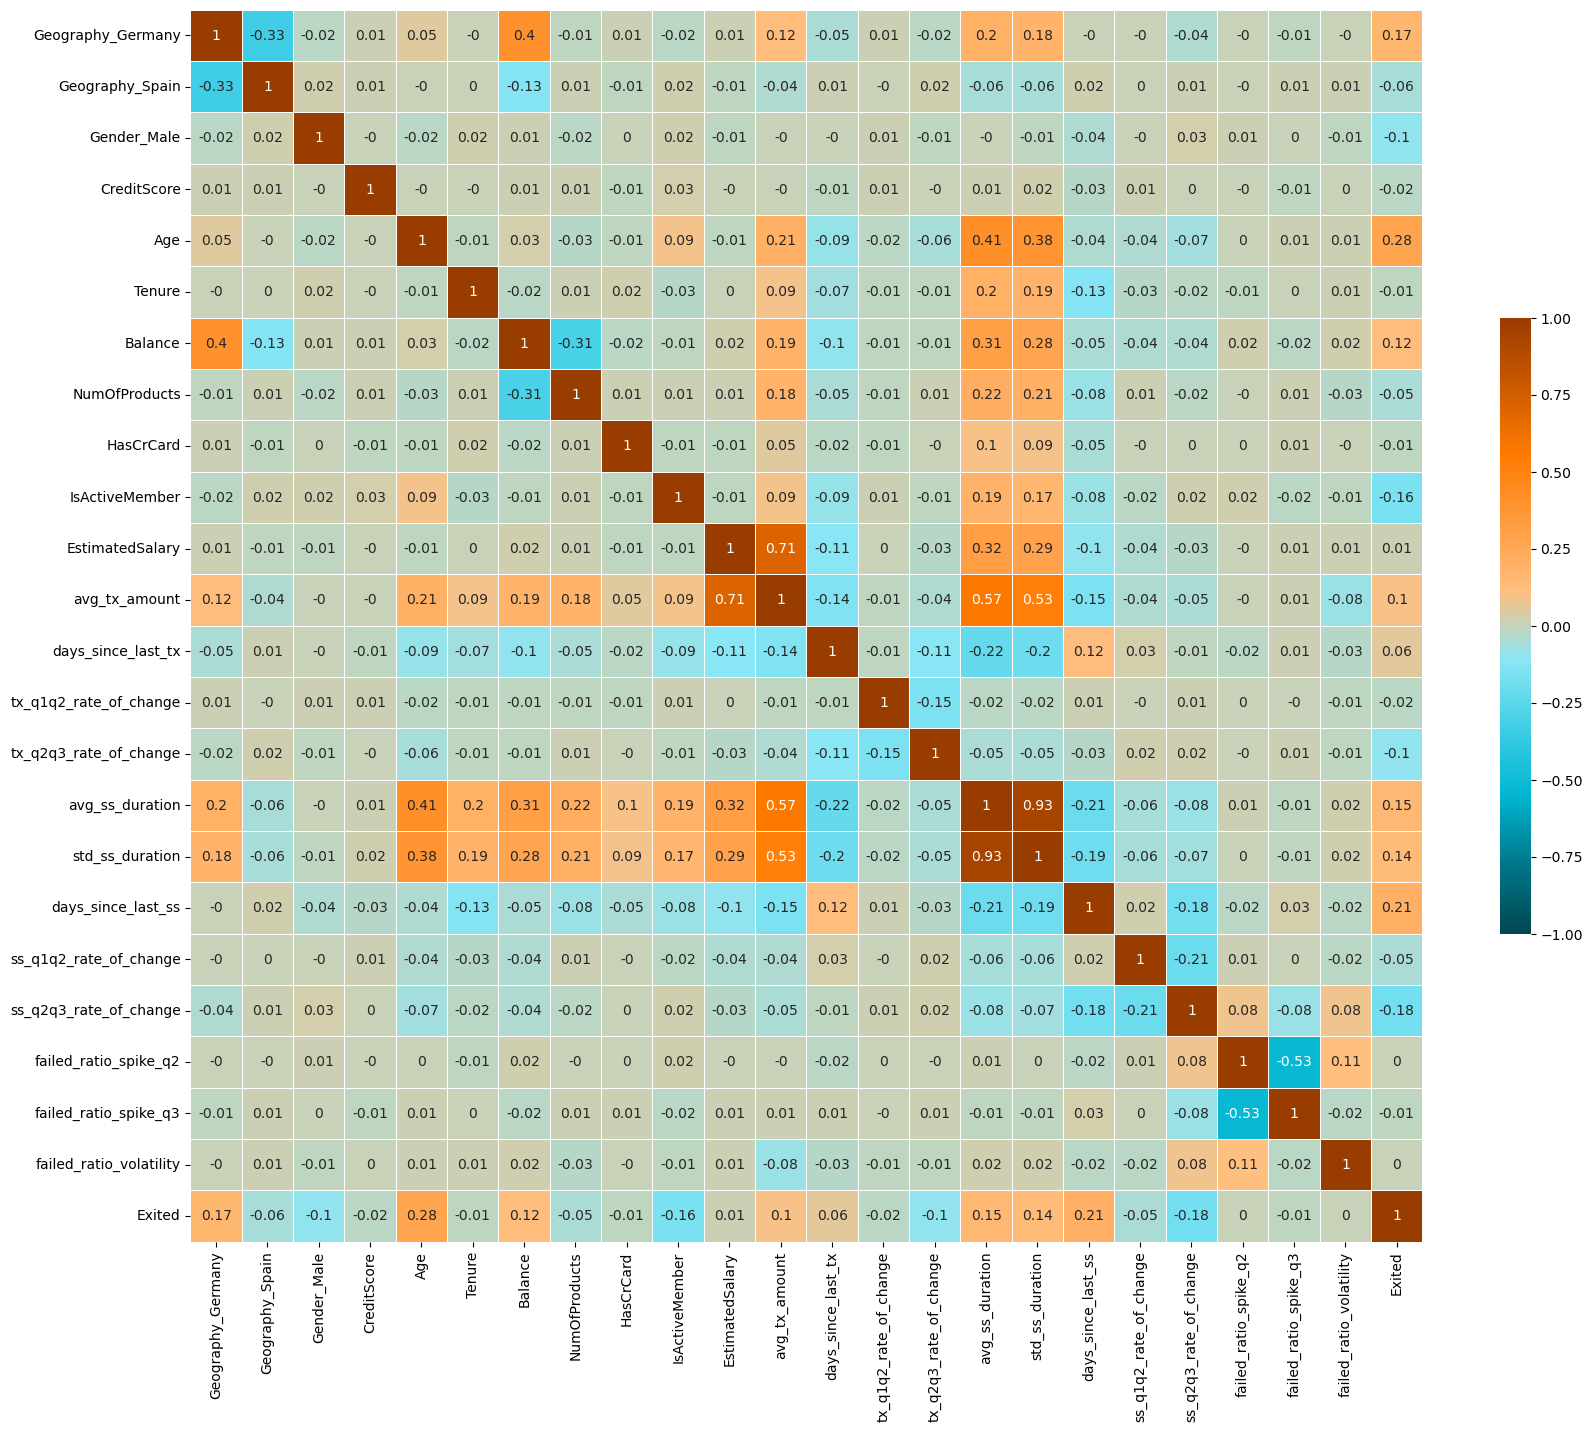

In [33]:
fig, ax = plt.subplots(figsize=(20,16))
ax = sns.heatmap(np.round(corr, 2), vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5}, cmap=custom_cmap2)
plt.show()

In [34]:
cols = corr.loc['Exited'].abs()[corr.loc['Exited'].abs() >= 0.05].index
corr_selected = corr[cols].loc[cols]

In [35]:
corr_selected

,Geography_Germany,Geography_Spain,Gender_Male,Age,Balance,IsActiveMember,avg_tx_amount,days_since_last_tx,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,Exited
Geography_Germany,1.000000,-0.330743,-0.022153,0.046498,0.398939,-0.015827,0.123151,-0.047058,-0.018900,0.203243,0.181946,-0.001415,-0.001849,-0.038121,0.166816
Geography_Spain,-0.330743,1.000000,0.019664,-0.001129,-0.131467,0.016092,-0.044419,0.010261,0.020893,-0.061617,-0.057422,0.017475,0.002181,0.011848,-0.055488
Gender_Male,-0.022153,0.019664,1.000000,-0.024786,0.014150,0.022241,-0.000187,-0.000160,-0.005906,-0.002986,-0.005531,-0.036799,-0.003138,0.033950,-0.103297
Age,0.046498,-0.001129,-0.024786,1.000000,0.026550,0.088727,0.208442,-0.090956,-0.055640,0.414476,0.382062,-0.044749,-0.043103,-0.069919,0.283042
Balance,0.398939,-0.131467,0.014150,0.026550,1.000000,-0.007848,0.188021,-0.097079,-0.014387,0.314447,0.277304,-0.045849,-0.039396,-0.039394,0.115705
IsActiveMember,-0.015827,0.016092,0.022241,0.088727,-0.007848,1.000000,0.089129,-0.092029,-0.010261,0.188406,0.174489,-0.081004,-0.015187,0.020415,-0.155129
avg_tx_amount,0.123151,-0.044419,-0.000187,0.208442,0.188021,0.089129,1.000000,-0.142980,-0.035537,0.571177,0.530423,-0.153551,-0.035777,-0.052749,0.100012
days_since_last_tx,-0.047058,0.010261,-0.000160,-0.090956,-0.097079,-0.092029,-0.142980,1.000000,-0.108686,-0.219280,-0.198136,0.123750,0.030472,-0.010862,0.061477
tx_q2q3_rate_of_change,-0.018900,0.020893,-0.005906,-0.055640,-0.014387,-0.010261,-0.035537,-0.108686,1.000000,-0.050439,-0.047710,-0.030876,0.020002,0.015866,-0.100205
avg_ss_duration,0.203243,-0.061617,-0.002986,0.414476,0.314447,0.188406,0.571177,-0.219280,-0.050439,1.000000,0.929898,-0.208444,-0.063686,-0.076949,0.148726


In [36]:
print(corr_selected)

                        Geography_Germany  Geography_Spain  Gender_Male  \
Geography_Germany                1.000000        -0.330743    -0.022153   
Geography_Spain                 -0.330743         1.000000     0.019664   
Gender_Male                     -0.022153         0.019664     1.000000   
Age                              0.046498        -0.001129    -0.024786   
Balance                          0.398939        -0.131467     0.014150   
IsActiveMember                  -0.015827         0.016092     0.022241   
avg_tx_amount                    0.123151        -0.044419    -0.000187   
days_since_last_tx              -0.047058         0.010261    -0.000160   
tx_q2q3_rate_of_change          -0.018900         0.020893    -0.005906   
avg_ss_duration                  0.203243        -0.061617    -0.002986   
std_ss_duration                  0.181946        -0.057422    -0.005531   
days_since_last_ss              -0.001415         0.017475    -0.036799   
ss_q1q2_rate_of_change   

In [37]:
# Generar una máscara para el triángulo superior
mascara = np.zeros_like(corr_selected, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

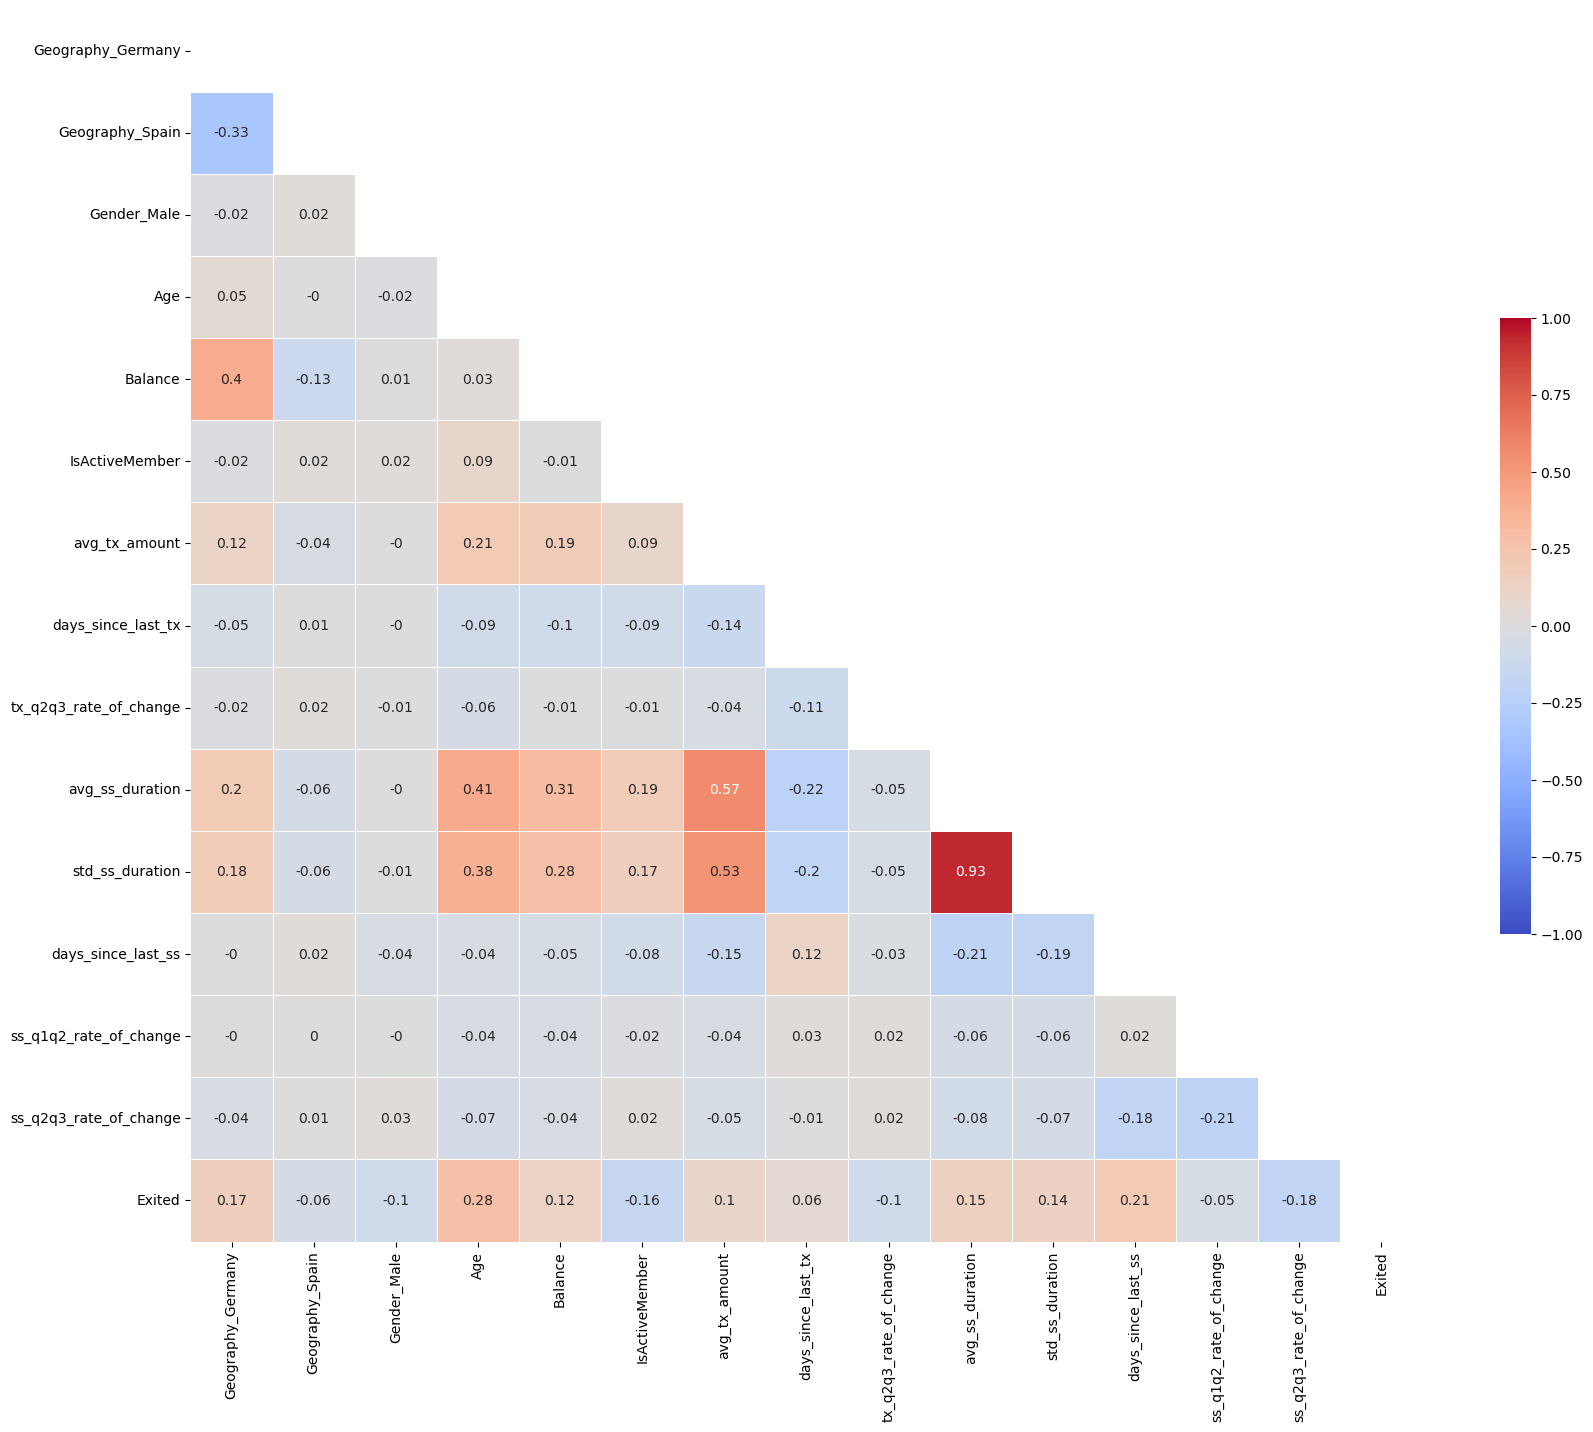

In [38]:
fig, ax = plt.subplots(figsize=(20,16))
ax = sns.heatmap(np.round(corr_selected, 2), mask=mascara, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5}, cmap='coolwarm')
fig.savefig(IMG_PATH / 'corr_matrix.png',
            transparent=False,
            dpi=300,
            bbox_inches='tight')
plt.show()

## <font color="#ff743d">**Train Test Split**</font>

In [39]:
y = df_encoded['Exited']
X = df_encoded.drop('Exited', axis=1)

In [40]:
X_train, X_test, y_train, y_test = tts(X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)

## <font color="#ff743d">**Escalado de variables numéricas**</font>

In [41]:
X.columns

Index(['Geography_Germany', 'Geography_Spain', 'Gender_Male', 'CreditScore',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'avg_tx_amount',
       'days_since_last_tx', 'tx_q1q2_rate_of_change',
       'tx_q2q3_rate_of_change', 'avg_ss_duration', 'std_ss_duration',
       'days_since_last_ss', 'ss_q1q2_rate_of_change',
       'ss_q2q3_rate_of_change', 'failed_ratio_spike_q2',
       'failed_ratio_spike_q3', 'failed_ratio_volatility'],
      dtype='object')

In [42]:
X_train.shape, X_test.shape

((7673, 23), (1919, 23))

In [43]:
col_order = X.columns

In [44]:
columns_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
                 'EstimatedSalary', 'avg_tx_amount', 'days_since_last_tx', 'tx_q1q2_rate_of_change',
               'tx_q2q3_rate_of_change', 'avg_ss_duration', 'std_ss_duration',
               'days_since_last_ss', 'ss_q1q2_rate_of_change',
               'ss_q2q3_rate_of_change', 'failed_ratio_spike_q2',
               'failed_ratio_spike_q3', 'failed_ratio_volatility']

# Separar las columnas numéricas y binarias/categóricas
X_train_num = X_train[columns_scale]
X_test_num = X_test[columns_scale]

X_train_binary = X_train.drop(columns_scale, axis=1)
X_test_binary = X_test.drop(columns_scale, axis=1)

# Escalar solo las columnas numéricas
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

# Reconstruir los DataFrames escalados, PRESERVANDO EL ÍNDICE
X_train_cols = pd.DataFrame(X_train_scaled, columns=columns_scale, index=X_train_num.index)
X_test_cols = pd.DataFrame(X_test_scaled, columns=columns_scale, index=X_test_num.index)

# Concatenar los DataFrames con los índices ahora alineados
X_train_final = pd.concat([X_train_cols, X_train_binary], axis=1)
X_test_final = pd.concat([X_test_cols, X_test_binary], axis=1)

# Verificación de las formas correctas
print(X_train_final.shape, X_test_final.shape)

(7673, 23) (1919, 23)


In [45]:
X_train_final.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,avg_tx_amount,days_since_last_tx,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard,IsActiveMember
5295,0.200000,0.500000,-1.00,0.275007,0.0,0.104554,-0.222671,0.6,-0.009436,-1.008449,0.035951,-0.042240,5.1,-0.455663,-1.087278,0.083333,-0.083333,0.650413,0.0,0.0,1.0,1.0,0.0
2570,-0.985185,0.083333,1.25,-0.103860,0.0,0.630156,0.823814,-0.2,-0.054354,0.276748,0.490328,1.065509,-0.3,-0.034670,0.047337,-0.043478,0.050000,0.213108,0.0,0.0,0.0,1.0,1.0
9354,-0.022222,0.500000,0.50,-0.132084,0.0,0.448313,0.803567,-0.4,-0.134208,-0.021841,0.222014,0.306076,-0.5,-0.130190,-0.952663,0.000000,0.000000,-0.354771,0.0,1.0,0.0,1.0,1.0
4785,-0.162963,0.250000,1.00,-0.766393,0.0,-1.033709,-0.832319,10.4,-1.292797,-1.251646,-1.024760,-1.023956,0.4,-0.455663,0.662722,0.000000,0.000000,-0.354771,0.0,0.0,1.0,1.0,0.0
640,-0.066667,-0.916667,-1.25,-0.766393,0.0,-0.547665,-0.606793,0.4,-1.315714,2.009409,-1.220528,-0.925645,-0.3,-0.740453,-0.683432,0.500000,-0.500000,5.676335,0.0,0.0,1.0,0.0,0.0


In [46]:
X_train = X_train_final[col_order].copy()
X_test = X_test_final[col_order].copy()

## <font color="#ff743d">**Balance del dataset de entrenamiento**</font>

In [47]:
smote = SMOTE(random_state=RANDOM_SEED)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [48]:
X_train.shape, y_train.shape

((12424, 23), (12424,))

In [49]:
y_train.sum()

6212

# <font color="#6e8ebc">**Modelado**</font>

In [50]:
skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=RANDOM_SEED)

In [51]:
best_models_results = []

## <font color="#ff743d">**Baseline Model - Decision Tree Classifier**</font>

In [52]:
baseline_model = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_SEED)
baseline_cross_val_results = cross_validate(baseline_model, X_train, y_train, cv=skf, scoring='recall')

In [53]:
cv_score_interval(results=baseline_cross_val_results, 
                  nombre='Baseline Model',
                  score='Recall')

Recall promedio de Baseline Model: 0.8604
Desviación estándar del Recall de Baseline Model: 0.0058
El Recall de Baseline Model estará entre [0.8488,0.8720] con un 95% de confianza


In [54]:
baseline_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

### <font color="#ffbf80">**Baseline Model - Métricas de Evaluación**</font>

In [55]:
baseline_train_results = metricas_evaluacion(modelo=baseline_model,
                                             stage='Train',
                                             x=X_train,
                                             y=y_train,
                                             nombre='Baseline Model')
baseline_train_results

{'Model': 'Baseline Model',
 'Stage': 'Train',
 'Accuracy': 0.9236,
 'Precision': 0.9369,
 'Recall': 0.9084,
 'F1-score': 0.9224,
 'AUC': 0.9759,
 'Umbral': 0.5}

In [56]:
baseline_results = metricas_evaluacion(baseline_model,
                                       stage='Test',
                                       x=X_test,
                                       y=y_test,
                                       nombre='Baseline Model')
baseline_results

{'Model': 'Baseline Model',
 'Stage': 'Test',
 'Accuracy': 0.8223,
 'Precision': 0.5263,
 'Recall': 0.6575,
 'F1-score': 0.5847,
 'AUC': 0.7909,
 'Umbral': 0.5}

### <font color="#ffbf80">**Baseline Model - Matriz de Confusión**</font>

In [57]:
baseline_pred = baseline_model.predict(X_test)

In [58]:
print(classification_report(y_test, baseline_pred))

              precision    recall  f1-score   support

           0       0.91      0.86      0.89      1554
           1       0.53      0.66      0.58       365

    accuracy                           0.82      1919
   macro avg       0.72      0.76      0.74      1919
weighted avg       0.84      0.82      0.83      1919



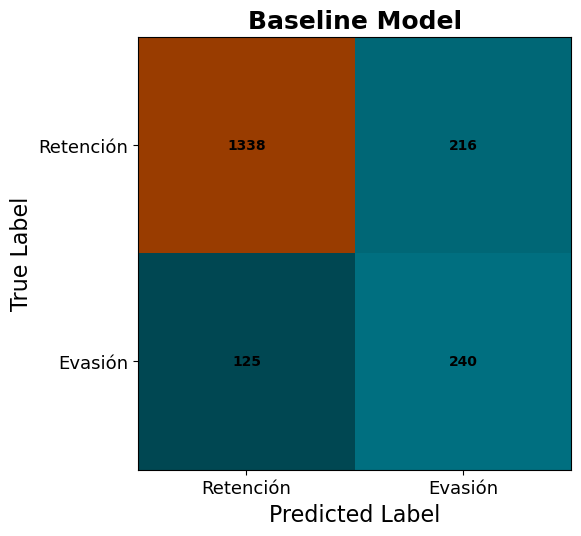

In [59]:
plot_conf_mat(baseline_model, X_test, y_test, 'Baseline Model', 'baseline')

### <font color="#ffbf80">**Baseline Model - Curva Precisión-Recall**</font>

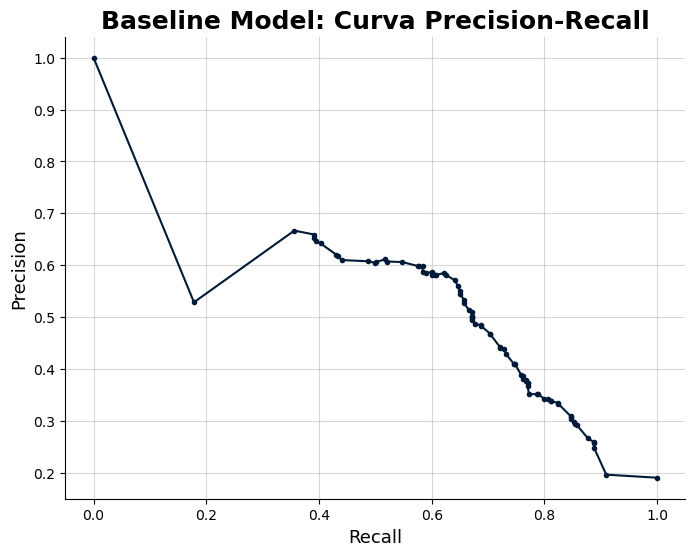

In [60]:
plot_precision_recall_curve(modelo=baseline_model,
                            x=X_test,
                            y=y_test,
                            nombre='Baseline Model')

### <font color="#ffbf80">**Baseline Model - Umbral de decisión**</font>

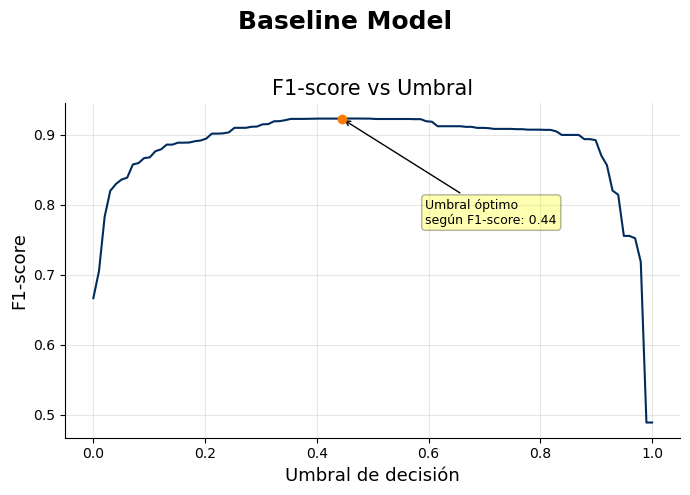

In [61]:
umbral_baseline, plot_umbral_baseline = plot_umbrales(modelo=baseline_model,
                                                      score='F1-score',
                                                      x=X_train,
                                                      y=y_train,
                                                      caja_x=0.15,
                                                      caja_y=0.15,
                                                      nombre='Baseline Model')

In [62]:
baseline_results_umbral = metricas_evaluacion(modelo=baseline_model,
                                              stage='Test',
                                              x=X_test,
                                              y=y_test,
                                              nombre='Baseline Model',
                                              umbral=umbral_baseline)
baseline_results_umbral

{'Model': 'Baseline Model',
 'Stage': 'Test',
 'Accuracy': 0.8145,
 'Precision': 0.5094,
 'Recall': 0.6712,
 'F1-score': 0.5792,
 'AUC': 0.7909,
 'Umbral': 0.4444444444444445}

### <font color="#ffbf80">**Baseline Model - Importancias**</font>

In [63]:
baseline_importances = baseline_model.feature_importances_

In [64]:
df_baseline_importances = pd.DataFrame({'Feature': X_train.columns, 'Importancia': baseline_importances})
df_baseline_importances = df_baseline_importances.sort_values(by='Importancia', ascending=False)

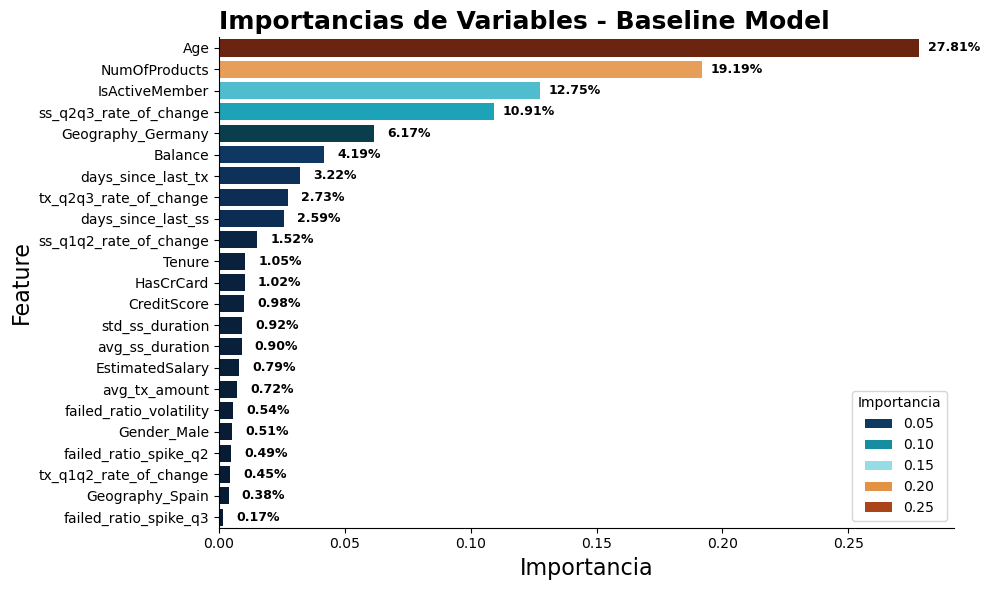

In [65]:
plot_analisis_variables(df=df_baseline_importances,
                        analisis='Importancia',
                        nombre_modelo='Baseline Model',
                        save='baseline_importances',
                        space=0.05,
                        cmap=reverse_custom_cmap)

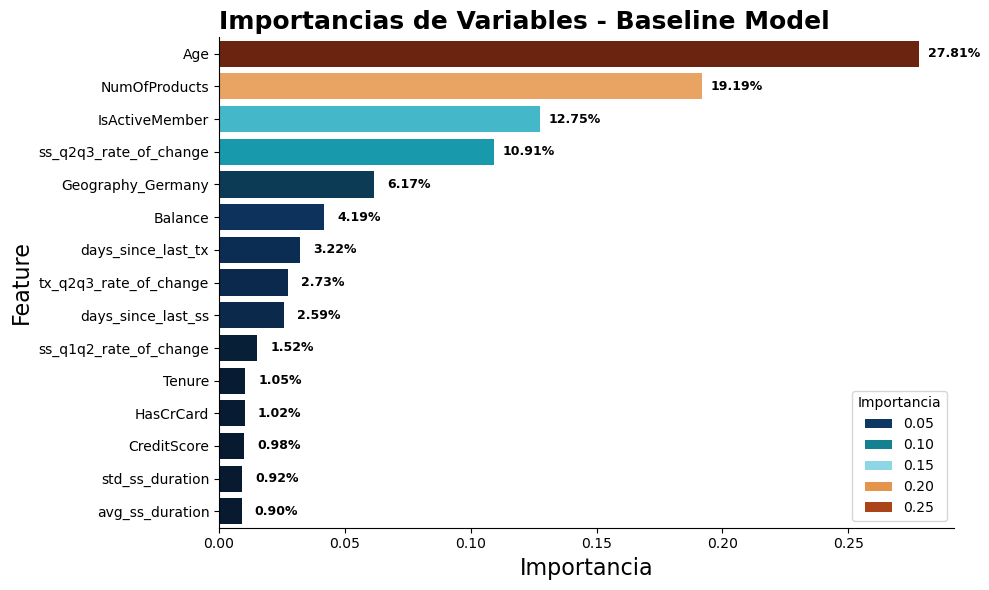

In [66]:
plot_analisis_variables(df=df_baseline_importances,
                        analisis='Importancia',
                        nombre_modelo='Baseline Model',
                        save='baseline_importances',
                        n_vars=15,
                        space=0.05,
                        cmap=reverse_custom_cmap)

In [67]:
df_baseline_importances['Importancia'].head().sum()

0.7683388526097819

In [68]:
df_baseline_importances

,Feature,Importancia
4,Age,0.278107
7,NumOfProducts,0.191888
9,IsActiveMember,0.127454
19,ss_q2q3_rate_of_change,0.109148
0,Geography_Germany,0.061742
6,Balance,0.041891
12,days_since_last_tx,0.032218
14,tx_q2q3_rate_of_change,0.027340
17,days_since_last_ss,0.025904
18,ss_q1q2_rate_of_change,0.015221


In [69]:
pd.DataFrame([baseline_train_results, baseline_results])

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,Baseline Model,Train,0.9236,0.9369,0.9084,0.9224,0.9759,0.5
1,Baseline Model,Test,0.8223,0.5263,0.6575,0.5847,0.7909,0.5


## <font color='#b23200'>**Conclusiones: Baseline Model - Decision Tree Classifier**</font>

El modelo base utilizado permite destacar algunas consideraciones que deberán tenerse en cuenta a lo largo de los experimentos futuros al entrenar distintas familias de modelos.

* Existe un claro sobreajuste a los datos de entrenamiento. Al comparar las métricas principales, es posible observar una clara caida al evaluar el modelo con el conjunto de prueba:
  - **Recall**: 0.9034 -> 0.6575
  - **F1-score**: 0.9138 -> 0.6107
  - **AUC**: 0.9722 -> 0.8125<br>
    
* El modelo reduce la impureza un 77.93% utilizando tan solo 5 variables. Esto es normal en **Árboles de Clasificación**, cuando el modelo encuentra una variable que reduce la impureza de Gini significativamente, la usa constantemente hasta sobreajustar. En este caso, las variables estáticas son predictores potentes, lo que genera que las señales de las variables de tendencia resulten opacadas por las variables del dataset original.


Dado que el modelo base (`Decision Tree Classifier`) se entrenó para ser utilizado como punto de partida, a continuación, se explorarán diferentes familias de algoritmos con el objetivo de tanto controlar el sobreajuste, para así mejorar el desempeño de los distintos modelos en los datos de prueba, como también buscar las respuestas a las preguntas anteriormente planteadas, y así encontrar aquel que presente el mejor comportamiento para ser deslpegado en un entorno productivo.

In [70]:
best_models_results.append(baseline_train_results)
best_models_results.append(baseline_results)
best_models_results.append(baseline_results_umbral)

In [71]:
pd.DataFrame(best_models_results)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,Baseline Model,Train,0.9236,0.9369,0.9084,0.9224,0.9759,0.500000
1,Baseline Model,Test,0.8223,0.5263,0.6575,0.5847,0.7909,0.500000
2,Baseline Model,Test,0.8145,0.5094,0.6712,0.5792,0.7909,0.444444


## <font color="#ff743d">**Random Forest**</font>

Una de las ventajas del algoritmo de **Random Forest** es que **entrena una numerosa cantidad de Árboles de Decisión**, **utilizando un subconjunto de variables**. Esto permite solucionar el problema con las variables estáticas mencionadas en las conclusiones del modelo base, ya que **en muchos de los arboles entrenados, dichos features no serán utilizados**. De esta manera será posible observar la importancia de las variables de tendencia generadas en el proceso de **Feature Engineering**.

In [72]:
rf_results_tracking = []

### <font color="#ffbf80">**RandomForest 1**</font>

In [73]:
rf_1 = RandomForestClassifier(max_depth=10, random_state=RANDOM_SEED)

In [74]:
rf_1_cross_val_results = cross_validate(rf_1, X_train, y_train, cv=skf, scoring='recall')

In [75]:
cv_score_interval(results=rf_1_cross_val_results, 
                  nombre='RandomForest 1',
                  score='Recall')

Recall promedio de RandomForest 1: 0.9115
Desviación estándar del Recall de RandomForest 1: 0.0037
El Recall de RandomForest 1 estará entre [0.9041,0.9189] con un 95% de confianza


In [76]:
rf_1.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [77]:
rf_1_train_results = metricas_evaluacion(modelo=rf_1,
                                             stage='Train',
                                             x=X_train,
                                             y=y_train,
                                             nombre='RandomForest 1')
rf_1_train_results

{'Model': 'RandomForest 1',
 'Stage': 'Train',
 'Accuracy': 0.9584,
 'Precision': 0.9602,
 'Recall': 0.9564,
 'F1-score': 0.9583,
 'AUC': 0.9931,
 'Umbral': 0.5}

In [78]:
rf_1_results = metricas_evaluacion(modelo=rf_1,
                                    stage='Test',
                                    x=X_test,
                                    y=y_test,
                                    nombre='RandomForest 1')
rf_1_results

{'Model': 'RandomForest 1',
 'Stage': 'Test',
 'Accuracy': 0.8713,
 'Precision': 0.6569,
 'Recall': 0.6767,
 'F1-score': 0.6667,
 'AUC': 0.8987,
 'Umbral': 0.5}

In [79]:
rf_1_importances = rf_1.feature_importances_
rf_1_importances

array([0.05383081, 0.01096149, 0.04495542, 0.01245725, 0.18304542,
       0.01219154, 0.04420928, 0.13902277, 0.01058943, 0.09613819,
       0.01262708, 0.02002311, 0.0500653 , 0.01449276, 0.03738216,
       0.02871222, 0.03054449, 0.04240047, 0.01896122, 0.10822508,
       0.01101306, 0.00900563, 0.00914583])

In [80]:
df_rf_1_importances = pd.DataFrame({'Feature': X_train.columns, 'Importancia': rf_1_importances})
df_rf_1_importances = df_rf_1_importances.sort_values(by='Importancia', ascending=False)

In [81]:
df_rf_1_importances

,Feature,Importancia
4,Age,0.183045
7,NumOfProducts,0.139023
19,ss_q2q3_rate_of_change,0.108225
9,IsActiveMember,0.096138
0,Geography_Germany,0.053831
12,days_since_last_tx,0.050065
2,Gender_Male,0.044955
6,Balance,0.044209
17,days_since_last_ss,0.042400
14,tx_q2q3_rate_of_change,0.037382


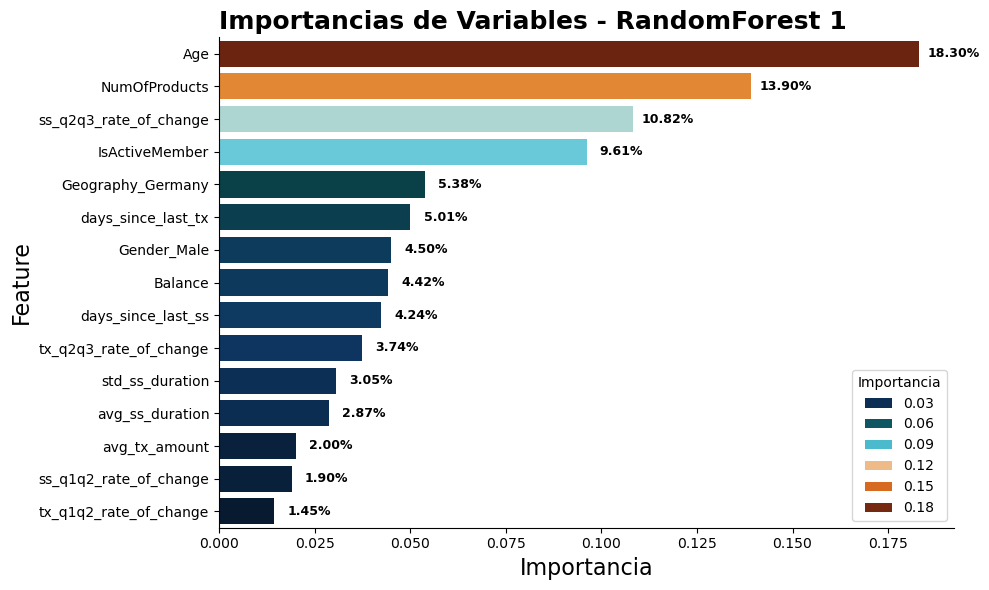

In [82]:
plot_analisis_variables(df=df_rf_1_importances,
                        analisis='Importancia',
                        nombre_modelo='RandomForest 1',
                        save='rf_1_importances',
                        n_vars=15,
                        space=0.05,
                        cmap=reverse_custom_cmap)

In [83]:
rf_results_tracking.append(rf_1_train_results)
rf_results_tracking.append(rf_1_results)

In [84]:
pd.DataFrame(best_models_results)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,Baseline Model,Train,0.9236,0.9369,0.9084,0.9224,0.9759,0.500000
1,Baseline Model,Test,0.8223,0.5263,0.6575,0.5847,0.7909,0.500000
2,Baseline Model,Test,0.8145,0.5094,0.6712,0.5792,0.7909,0.444444


In [85]:
pd.DataFrame(rf_results_tracking)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,RandomForest 1,Train,0.9584,0.9602,0.9564,0.9583,0.9931,0.5
1,RandomForest 1,Test,0.8713,0.6569,0.6767,0.6667,0.8987,0.5


In [86]:
df_rf_1_importances.head(15)

,Feature,Importancia
4,Age,0.183045
7,NumOfProducts,0.139023
19,ss_q2q3_rate_of_change,0.108225
9,IsActiveMember,0.096138
0,Geography_Germany,0.053831
12,days_since_last_tx,0.050065
2,Gender_Male,0.044955
6,Balance,0.044209
17,days_since_last_ss,0.042400
14,tx_q2q3_rate_of_change,0.037382


In [87]:
df_baseline_importances.head(15)

,Feature,Importancia
4,Age,0.278107
7,NumOfProducts,0.191888
9,IsActiveMember,0.127454
19,ss_q2q3_rate_of_change,0.109148
0,Geography_Germany,0.061742
6,Balance,0.041891
12,days_since_last_tx,0.032218
14,tx_q2q3_rate_of_change,0.027340
17,days_since_last_ss,0.025904
18,ss_q1q2_rate_of_change,0.015221


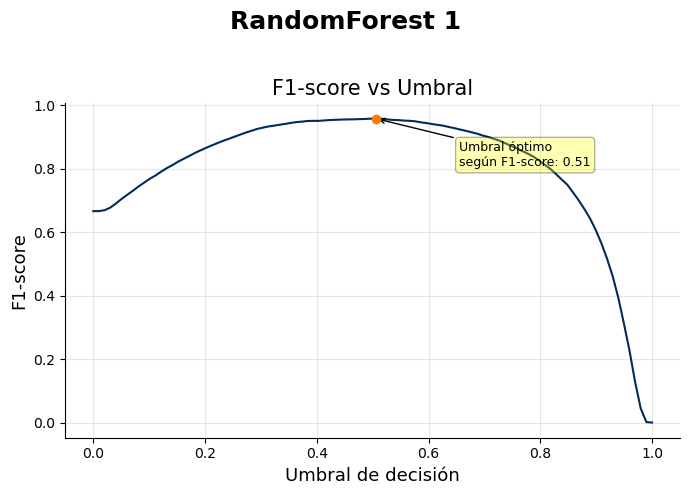

In [88]:
umbral_rf_1, plot_umbral_rf_1 = plot_umbrales(modelo=rf_1,
                                                      score='F1-score',
                                                      x=X_train,
                                                      y=y_train,
                                                      caja_x=0.15,
                                                      caja_y=0.15,
                                                      nombre='RandomForest 1')

In [89]:
rf_1_results_umbral = metricas_evaluacion(modelo=rf_1,
                                    stage='Test',
                                    x=X_test,
                                    y=y_test,
                                    nombre='RandomForest 1',
                                    umbral=umbral_rf_1)
rf_1_results_umbral

{'Model': 'RandomForest 1',
 'Stage': 'Test',
 'Accuracy': 0.8739,
 'Precision': 0.6658,
 'Recall': 0.6767,
 'F1-score': 0.6712,
 'AUC': 0.8987,
 'Umbral': 0.5050505050505051}

### <font color="#8ae6f4">**Observaciones: RandomForest 1**</font>

Se puede ver que utilizando solo los mismos hiperparámetros que se usaron en `Baseline Model` para controlar la profundidad de los árboles (`max_depth=10`), se produce una mejora significativa en las métricas generales.

Principalmente, el valor del **Área Bajo la Curva *(AUC — Area Under the Curve)* cae aproximadamente 7% menos que en el caso del modelo base**. Mientras que la Precisión obtiene una mejora significativa de aproximadamente **13%**.

Sin embargo, **la métrica prioritaria** para el problema es el **Recall**, dado que el objetivo es identificar correctamente aquellos clientes que planean irse. Esta métrica **se mantiene prácticamente igual en relación al modelo base**.

En cuanto a las importancias, se producen algunas alteraciones en el orden de importancia de los features. Algunas características de tendencias, consiguen superar a otras estáticas que previamente las opacaban. Esto se puede apreciar además un **aplanamiento en los valores de dichas importancias**, por ejemplo, Age antes separaba las clases en un 27.62% y ahora lo hace un 16.87%, aunque siga siendo el predictor predominante.

### <font color="#ffbf80">**RandomForest 2 - n_estimators=200**</font>

In [90]:
rf_2 = RandomForestClassifier(max_depth=10, n_estimators=200, random_state=RANDOM_SEED)

In [91]:
rf_2.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [92]:
rf_2_train_results = metricas_evaluacion(modelo=rf_2,
                                             stage='Train',
                                             x=X_train,
                                             y=y_train,
                                             nombre='RandomForest 2')
rf_2_train_results

{'Model': 'RandomForest 2',
 'Stage': 'Train',
 'Accuracy': 0.9577,
 'Precision': 0.96,
 'Recall': 0.9552,
 'F1-score': 0.9576,
 'AUC': 0.9933,
 'Umbral': 0.5}

In [93]:
rf_2_results = metricas_evaluacion(modelo=rf_2,
                                     stage='Test',
                                     x=X_test,
                                     y=y_test,
                                     nombre='RandomForest 2')
rf_2_results

{'Model': 'RandomForest 2',
 'Stage': 'Test',
 'Accuracy': 0.8749,
 'Precision': 0.6658,
 'Recall': 0.6877,
 'F1-score': 0.6765,
 'AUC': 0.8995,
 'Umbral': 0.5}

In [94]:
rf_results_tracking.append(rf_2_train_results)
rf_results_tracking.append(rf_2_results)

In [95]:
pd.DataFrame(rf_results_tracking)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,RandomForest 1,Train,0.9584,0.9602,0.9564,0.9583,0.9931,0.5
1,RandomForest 1,Test,0.8713,0.6569,0.6767,0.6667,0.8987,0.5
2,RandomForest 2,Train,0.9577,0.9600,0.9552,0.9576,0.9933,0.5
3,RandomForest 2,Test,0.8749,0.6658,0.6877,0.6765,0.8995,0.5


### <font color="#8ae6f4">**Observaciones: RandomForest 2 - n_estimators=200**</font>

Aumentar el numero predefinido de estimadores a 200 no produce ningún cambio significativo.

### <font color="#ffbf80">**RandomForest 3 - GridSearchCV**</font>

In [96]:
warnings.filterwarnings('error')

param_grid = {
    'max_depth': [5, 7, 10],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2, 3],
    'n_estimators': [100, 150]
}

rf_3 = GridSearchCV(RandomForestClassifier(random_state=RANDOM_SEED, class_weight='balanced'),
                    param_grid=param_grid, scoring='recall',
                    cv=skf,
                    n_jobs=-1)

start_time = timer()
rf_3.fit(X_train, y_train)
end_time = timer()

In [97]:
rf_3_ttime = print_timediff(start=start_time,
                            end=end_time,
                           nombre_modelo='RandomForest 3')

Tiempo de entrenamiento de RandomForest 3: 108.9728 seconds


In [98]:
rf_3_train_results = metricas_evaluacion(modelo=rf_3,
                                         stage='Train',
                                         x=X_train,
                                         y=y_train,
                                         nombre='RandomForest 3')
rf_3_train_results

{'Model': 'RandomForest 3',
 'Stage': 'Train',
 'Accuracy': 0.9581,
 'Precision': 0.9602,
 'Recall': 0.9559,
 'F1-score': 0.9581,
 'AUC': 0.9932,
 'Umbral': 0.5}

In [99]:
rf_3_results = metricas_evaluacion(modelo=rf_3,
                                         stage='Test',
                                         x=X_test,
                                         y=y_test,
                                         nombre='RandomForest 3')
rf_3_results

{'Model': 'RandomForest 3',
 'Stage': 'Test',
 'Accuracy': 0.876,
 'Precision': 0.6684,
 'Recall': 0.6904,
 'F1-score': 0.6792,
 'AUC': 0.8993,
 'Umbral': 0.5}

In [100]:
rf_3.best_params_

{'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 3,
 'n_estimators': 100}

In [101]:
rf_results_tracking.append(rf_3_train_results)
rf_results_tracking.append(rf_3_results)

In [102]:
pd.DataFrame(rf_results_tracking)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,RandomForest 1,Train,0.9584,0.9602,0.9564,0.9583,0.9931,0.5
1,RandomForest 1,Test,0.8713,0.6569,0.6767,0.6667,0.8987,0.5
2,RandomForest 2,Train,0.9577,0.9600,0.9552,0.9576,0.9933,0.5
3,RandomForest 2,Test,0.8749,0.6658,0.6877,0.6765,0.8995,0.5
4,RandomForest 3,Train,0.9581,0.9602,0.9559,0.9581,0.9932,0.5
5,RandomForest 3,Test,0.8760,0.6684,0.6904,0.6792,0.8993,0.5


### <font color="#8ae6f4">**Observaciones: RandomForest 3 - GridSearchCV**</font>

La optimización de hiperparámetros mantuvo las métricas generales del modelo muy similares al experimento anterior.

Dado que se están utilizando datos generados sintéticamente, y que el tiempo para ajustarlos y considerar variaciones y patrones presentes en la vida real, el mayor problema es realmente el sobreajuste, por lo que es posible que al realizar una búsqueda óptima, el modelo consiga memorizar fácilmente los patrones existentes y pierda de vista el las relaciones generales de dichas características.

Para corroborar esto, se realizará una búsqueda con mayor amplitud de valores, y ver si este fenómeno presiste.

### <font color="#ffbf80">**RandomForest 4**</font>

In [103]:
rf_4 = RandomForestClassifier(random_state=RANDOM_SEED)

In [104]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [105]:
param_dist = {
    'n_estimators': randint(100, 1000),
    'max_depth': randint(5, 15),
    'min_samples_leaf': randint(1, 10),
    'min_samples_split': randint(2, 10),
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}


random_search = RandomizedSearchCV(
    rf_4,
    param_distributions=param_dist,
    n_iter=150,
    cv=skf,
    scoring='recall',
    random_state=RANDOM_SEED,
    n_jobs=-1
)


In [106]:
start_time = timer()
random_search.fit(X_train, y_train)
end_time = timer()

In [107]:
rf_4_ttime = print_timediff(start=start_time,
                            end=end_time,
                            nombre_modelo='RandomForest 4')

Tiempo de entrenamiento de RandomForest 4: 1836.1190 seconds


In [108]:
rf_4_train_results = metricas_evaluacion(modelo=random_search.best_estimator_,
                                         stage='Train',
                                         x=X_train,
                                         y=y_train,
                                         nombre='RandomForest 4')
rf_4_train_results

{'Model': 'RandomForest 4',
 'Stage': 'Train',
 'Accuracy': 0.9906,
 'Precision': 0.9911,
 'Recall': 0.99,
 'F1-score': 0.9906,
 'AUC': 0.9996,
 'Umbral': 0.5}

In [109]:
rf_4_results = metricas_evaluacion(modelo=random_search.best_estimator_,
                                         stage='Test',
                                         x=X_test,
                                         y=y_test,
                                         nombre='RandomForest 4')
rf_4_results

{'Model': 'RandomForest 4',
 'Stage': 'Test',
 'Accuracy': 0.8786,
 'Precision': 0.6864,
 'Recall': 0.6658,
 'F1-score': 0.6759,
 'AUC': 0.8999,
 'Umbral': 0.5}

In [110]:
rf_4 = random_search.best_estimator_

In [111]:
rf_results_tracking.append(rf_4_train_results)
rf_results_tracking.append(rf_4_results)

In [112]:
df_rf = pd.DataFrame(rf_results_tracking)

In [113]:
df_rf

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,RandomForest 1,Train,0.9584,0.9602,0.9564,0.9583,0.9931,0.5
1,RandomForest 1,Test,0.8713,0.6569,0.6767,0.6667,0.8987,0.5
2,RandomForest 2,Train,0.9577,0.9600,0.9552,0.9576,0.9933,0.5
3,RandomForest 2,Test,0.8749,0.6658,0.6877,0.6765,0.8995,0.5
4,RandomForest 3,Train,0.9581,0.9602,0.9559,0.9581,0.9932,0.5
5,RandomForest 3,Test,0.8760,0.6684,0.6904,0.6792,0.8993,0.5
6,RandomForest 4,Train,0.9906,0.9911,0.9900,0.9906,0.9996,0.5
7,RandomForest 4,Test,0.8786,0.6864,0.6658,0.6759,0.8999,0.5


In [114]:
df_rf[df_rf['Stage'] == 'Test']

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
1,RandomForest 1,Test,0.8713,0.6569,0.6767,0.6667,0.8987,0.5
3,RandomForest 2,Test,0.8749,0.6658,0.6877,0.6765,0.8995,0.5
5,RandomForest 3,Test,0.8760,0.6684,0.6904,0.6792,0.8993,0.5
7,RandomForest 4,Test,0.8786,0.6864,0.6658,0.6759,0.8999,0.5


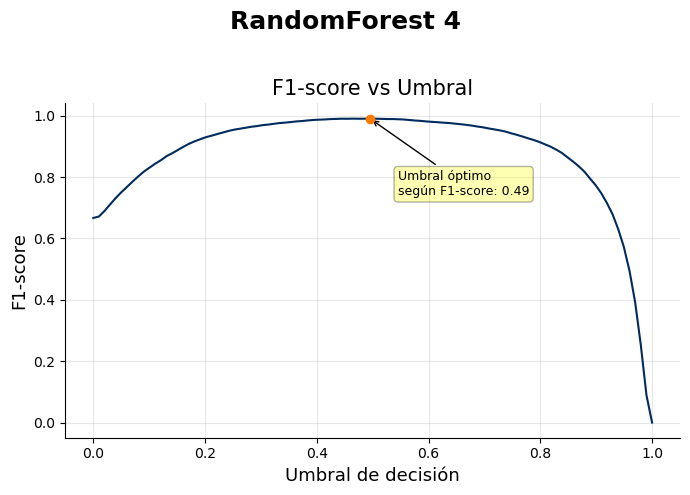

In [115]:
umbral_rf_4, plot_umbral_rf_4 = plot_umbrales(modelo=rf_4,
                                                      score='F1-score',
                                                      x=X_train,
                                                      y=y_train,
                                                      caja_x=0.05,
                                                      caja_y=0.25,
                                                      nombre='RandomForest 4')

In [116]:
rf_4_results_umbral = metricas_evaluacion(modelo=rf_4,
                                         stage='Test',
                                         x=X_test,
                                         y=y_test,
                                         nombre='RandomForest 4',
                                         umbral=umbral_rf_4)
rf_4_results_umbral

{'Model': 'RandomForest 4',
 'Stage': 'Test',
 'Accuracy': 0.8791,
 'Precision': 0.6863,
 'Recall': 0.6712,
 'F1-score': 0.6787,
 'AUC': 0.8999,
 'Umbral': 0.494949494949495}

### <font color="#8ae6f4">**Observaciones: RandomForest 4 - RandomizedSearch**</font>

Si bien el modelo entrenado con la búsqueda aleatoria de hiperparámetros sobreajusta a los datos de entrenamiento más que cualquiera de los anteriores entrenados dentro de esta familia, a su vez es el que consigue el mejor valor de **Área Bajo la Curva (AUC)**, lo que indica que es el que mejor consigue separar las clases.

Por lo que se conservará `RandomForest 4` como modelo representante de esta familia.

## <font color='#b23200'>**Conclusiones: Random Forest**</font>

Luego de llevar a cabo 4 experimentos dentro de la familia **Random Forest**, se consiguió mejorar las métricas generales en relación al modelo utilizado como base: **Decision Tree Classifier**.

| Modelo         | Stage  | Accuracy  | Precision   | Recall    | F1-Score    | AUC      |
|----------------|--------|-----------|-------------|-----------|-------------|----------|
| Baseline Model | Train  |	0.9215	  | 0.9247	    | 0.9177	| 0.9212	  | 0.9758   |
| Baseline Model | Test	  | 0.8275	  | 0.5362	    | 0.6529	| 0.5888	  | 0.8134   |
| RandomForest 4 | Train  | 0.9866	  | 0.9857	    | 0.9875	| 0.9866	  | 0.9992	 |
| RandomForest 4 | Test	  | 0.8765	  | 0.7006	    | 0.6061	| 0.6499	  | 0.8893	 |

Al observar las importancias, la selección reducida de variables de los estimadores de **Random Forest** permitió evitar una elevada dependencia en unas pocas variables principales, lo que se tradujo en una mejora en las métricas generales.

Dado que el conjunto de Test no se balancea para no afectar la distribución real de los datos, al observar el valor AUC de ambos modelos en el conjunto **Test**, vemos que `RandomForest 4` consigue un área bajo la curva de 0.8893, es decir, +0.0759, y con un **F1-Score 0.0611** mayor.



In [117]:
best_models_results.append(rf_4_results_umbral)

In [118]:
try:
    with open(MODELS_PATH / 'random_forest.pkl', 'wb') as f:
        pickle.dump(rf_4, f)
except Exception as e:
    print(e)
    print('No se pudo guardar Random Forest')

## <font color="#ff743d">**Logistic Regression**</font>

A diferencia del modelo RandomForest, la Regresión Logística es sensible a outliers y a la escala de los datos. Además, a menos que se utilice la regularización Lasso que penaliza la complejidad del modelo, este, también es sensible a la multicolinealidad.

Sin embargo, en el paso anterior (EDA) se realizó el análisis VIF para corroborar que no existiera una marcada multicolinealidad entre las variables, y los datos fueron escalados para abordar con la sensibilidad de modelos como este.

In [119]:
lr_results_tracking = []

### <font color="#ffbf80">**LogisticRegression 1**</font>

In [120]:
lr_1 = LogisticRegression(max_iter=10000, random_state=RANDOM_SEED)

In [121]:
lr_1.fit(X_train, y_train)

LogisticRegression(max_iter=10000, random_state=42)

In [122]:
lr_1_train_results = metricas_evaluacion(modelo=lr_1,
                                         stage='Train',
                                         x=X_train,
                                         y=y_train,
                                         nombre='LogisticRegression 1')
lr_1_train_results

{'Model': 'LogisticRegression 1',
 'Stage': 'Train',
 'Accuracy': 0.779,
 'Precision': 0.7748,
 'Recall': 0.7865,
 'F1-score': 0.7806,
 'AUC': 0.8559,
 'Umbral': 0.5}

In [123]:
lr_1_results = metricas_evaluacion(modelo=lr_1,
                                         stage='Test',
                                         x=X_test,
                                         y=y_test,
                                         nombre='LogisticRegression 1')
lr_1_results

{'Model': 'LogisticRegression 1',
 'Stage': 'Test',
 'Accuracy': 0.7801,
 'Precision': 0.4551,
 'Recall': 0.7918,
 'F1-score': 0.578,
 'AUC': 0.8656,
 'Umbral': 0.5}

In [124]:
lr_results_tracking.append(lr_1_train_results)
lr_results_tracking.append(lr_1_results)

In [125]:
pd.DataFrame(lr_results_tracking)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,LogisticRegression 1,Train,0.7790,0.7748,0.7865,0.7806,0.8559,0.5
1,LogisticRegression 1,Test,0.7801,0.4551,0.7918,0.5780,0.8656,0.5


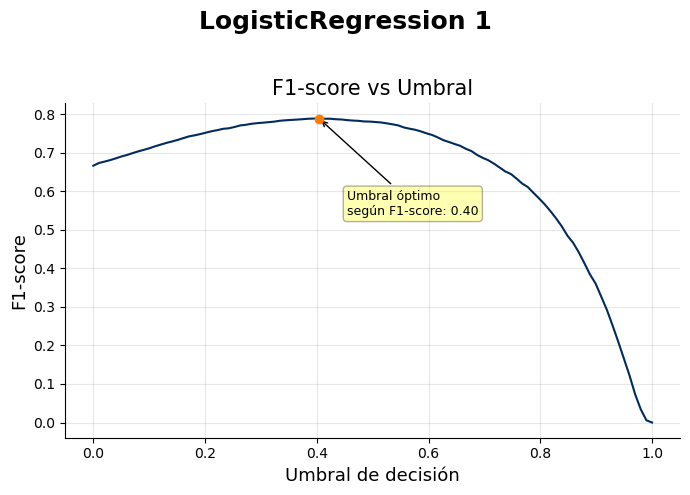

In [126]:
umbral_lr_1, plot_umbral_lr_1 = plot_umbrales(modelo=lr_1,
                                                      score='F1-score',
                                                      x=X_train,
                                                      y=y_train,
                                                      caja_x=0.05,
                                                      caja_y=0.25,
                                                      nombre='LogisticRegression 1')

In [127]:
lr_1_results_umbral = metricas_evaluacion(modelo=lr_1,
                                         stage='Test',
                                         x=X_test,
                                         y=y_test,
                                         nombre='LogisticRegression 1',
                                         umbral=umbral_lr_1)
lr_1_results_umbral

{'Model': 'LogisticRegression 1',
 'Stage': 'Test',
 'Accuracy': 0.7191,
 'Precision': 0.3923,
 'Recall': 0.8685,
 'F1-score': 0.5405,
 'AUC': 0.8656,
 'Umbral': 0.4040404040404041}

### <font color="#8ae6f4">**Observaciones: LogisticRegression 1**</font>

La **regresión logística** con sus valores de entrenamiento por defecto y utilizando el **umbral de decisión óptimo** de acuerdo a la métrica **F1-Score**, consigue identificar a la clase objetivo (`Exited = 1`) con muy buenos resultados, obteniendo un **Recall = 0.8685**. 

Sin embargo, para alcanzar estás métricas, el modelo solo consigue clasificar correctamente a menos del 40% de casos que no se irán, obteniendo una **Precisión = 0.3923**. 

Esto implica que, para conseguir **clasificar correctamente casi el 87% de casos de abandono, el modelo se equivoca el 60% de veces con respecto a clientes que no abandonarán la empresa**, lo cual se traduce en **campañas de retención ineficientes en costos** y **clientes molestos por intervenciones innecesarias**.

Se buscará mejorar el desepeño de `LogisticRegression 1` a traves de diversos experimentos, modificando los hiperparámetros del algoritmo con el objetivo de obtener métricas más balanceadas.

### <font color="#ffbf80">**LogisticRegression 2 - Penalty Lasso (L1)**</font>

In [128]:
lr_2 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=RANDOM_SEED, class_weight='balanced')

In [129]:
lr_2.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', penalty='l1', random_state=42,
                   solver='liblinear')

In [130]:
lr_2_train_results = metricas_evaluacion(modelo=lr_2,
                                         stage='Train',
                                         x=X_train,
                                         y=y_train,
                                         nombre='LogisticRegression 2')
lr_2_train_results

{'Model': 'LogisticRegression 2',
 'Stage': 'Train',
 'Accuracy': 0.7787,
 'Precision': 0.7747,
 'Recall': 0.7861,
 'F1-score': 0.7803,
 'AUC': 0.8559,
 'Umbral': 0.5}

In [131]:
lr_2_results = metricas_evaluacion(modelo=lr_2,
                                         stage='Test',
                                         x=X_test,
                                         y=y_test,
                                         nombre='LogisticRegression 2')
lr_2_results

{'Model': 'LogisticRegression 2',
 'Stage': 'Test',
 'Accuracy': 0.7791,
 'Precision': 0.4537,
 'Recall': 0.7918,
 'F1-score': 0.5768,
 'AUC': 0.8655,
 'Umbral': 0.5}

In [132]:
lr_results_tracking.append(lr_2_train_results)
lr_results_tracking.append(lr_2_results)

In [133]:
pd.DataFrame(lr_results_tracking)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,LogisticRegression 1,Train,0.7790,0.7748,0.7865,0.7806,0.8559,0.5
1,LogisticRegression 1,Test,0.7801,0.4551,0.7918,0.5780,0.8656,0.5
2,LogisticRegression 2,Train,0.7787,0.7747,0.7861,0.7803,0.8559,0.5
3,LogisticRegression 2,Test,0.7791,0.4537,0.7918,0.5768,0.8655,0.5


### <font color="#8ae6f4">**Observaciones: LogisticRegression 2**</font>

Los resultados obtenidos por `LogisticRegression 2` son prácticamente similares al utilizar la **penalización Lasso (L1)**, la cual castiga el uso excesivo de variables, llevando los coeficientes de aquellas que no considera necesarias a 0.

Aún utilizando menor cantidad de variables, los resultados con casi idénticos a los de `LogisticRegression 1`. Esto indica que el principal problema para mejorar el desempeño del modelo no se encuentra en las cantidad de variables sino en sus hiperparámetros. Por lo que se realizará una búsqueda para encontrar aquellos que mejor se ajusten a los datos disponibles.

### <font color="#ffbf80">**LogisticRegression 3 - GridSearchCV**</font>

In [134]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs'],            
    'max_iter': [100, 150, 200]
}

lr_3 = GridSearchCV(LogisticRegression(random_state=RANDOM_SEED),
                    param_grid=param_grid, 
                    scoring='recall',
                    cv=skf)

lr_3.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=6, random_state=42, shuffle=True),
             estimator=LogisticRegression(random_state=42),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'max_iter': [100, 150, 200], 'solver': ['lbfgs']},
             scoring='recall')

In [135]:
lr_3_train_results = metricas_evaluacion(modelo=lr_3,
                                         stage='Train',
                                         x=X_train,
                                         y=y_train,
                                         nombre='LogisticRegression 3')
lr_3_train_results

{'Model': 'LogisticRegression 3',
 'Stage': 'Train',
 'Accuracy': 0.7817,
 'Precision': 0.7779,
 'Recall': 0.7886,
 'F1-score': 0.7832,
 'AUC': 0.8558,
 'Umbral': 0.5}

In [136]:
lr_3_results = metricas_evaluacion(modelo=lr_3,
                                         stage='Test',
                                         x=X_test,
                                         y=y_test,
                                         nombre='LogisticRegression 3')
lr_3_results

{'Model': 'LogisticRegression 3',
 'Stage': 'Test',
 'Accuracy': 0.778,
 'Precision': 0.4524,
 'Recall': 0.7945,
 'F1-score': 0.5765,
 'AUC': 0.8663,
 'Umbral': 0.5}

In [137]:
lr_results_tracking.append(lr_3_train_results)
lr_results_tracking.append(lr_3_results)

In [138]:
pd.DataFrame(lr_results_tracking)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,LogisticRegression 1,Train,0.7790,0.7748,0.7865,0.7806,0.8559,0.5
1,LogisticRegression 1,Test,0.7801,0.4551,0.7918,0.5780,0.8656,0.5
2,LogisticRegression 2,Train,0.7787,0.7747,0.7861,0.7803,0.8559,0.5
3,LogisticRegression 2,Test,0.7791,0.4537,0.7918,0.5768,0.8655,0.5
4,LogisticRegression 3,Train,0.7817,0.7779,0.7886,0.7832,0.8558,0.5
5,LogisticRegression 3,Test,0.7780,0.4524,0.7945,0.5765,0.8663,0.5


### <font color="#8ae6f4">**Observaciones: LogisticRegression 3 - GridSearchCV**</font>

A pesar de realizar la búsqueda para encontrar los hiperparámetros del modelo que mejor se ajusten a los datos no se consiguen mejoras significativas en lás métricas de evaluación.

El modelo sigue sobreajustando a los datos de entrenamientos para la clase mayoritaria (`Exited = 0`), lo cual lo lleva a cometer demasiados errores al clasificar a los clientes como **"abandono"**.

Dado que `LogisticRegression 3` consigue los mejores valores en **Recall** y **AUC** sobre los datos de prueba, se conservará este modelo como representante de esta familia.

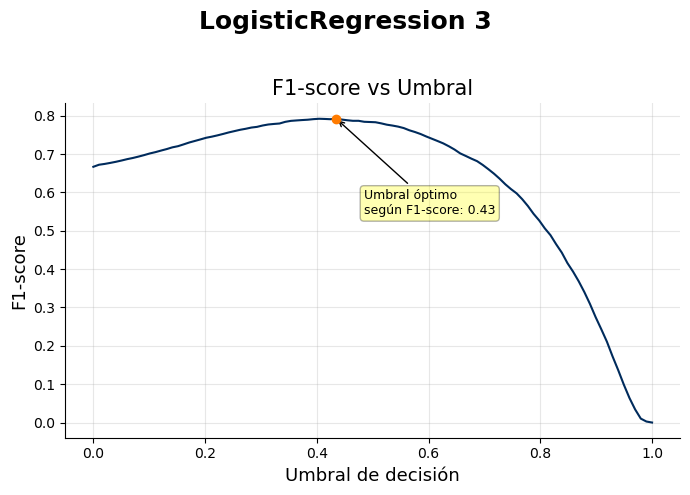

In [139]:
umbral_lr_3, plot_umbral_lr_3 = plot_umbrales(modelo=lr_3,
                                              score='F1-score',
                                              x=X_train,
                                              y=y_train,
                                              caja_x=0.05,
                                              caja_y=0.25,
                                              nombre='LogisticRegression 3')

In [140]:
lr_3_results_umbral = metricas_evaluacion(modelo=lr_3,
                                         stage='Test',
                                         x=X_test,
                                         y=y_test,
                                         nombre='LogisticRegression 3',
                                         umbral=umbral_lr_3)
lr_3_results_umbral

{'Model': 'LogisticRegression 3',
 'Stage': 'Test',
 'Accuracy': 0.7342,
 'Precision': 0.405,
 'Recall': 0.8466,
 'F1-score': 0.5479,
 'AUC': 0.8663,
 'Umbral': 0.43434343434343436}

In [141]:
try:
    with open(MODELS_PATH / 'logistic_regression.pkl', 'wb') as f:
        pickle.dump(lr_3, f)
except Exception as e:
    print(e)
    print('No se pudo guardar Logistic Regression')

In [142]:
best_models_results.append(lr_3_results_umbral)

In [143]:
pd.DataFrame(best_models_results)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,Baseline Model,Train,0.9236,0.9369,0.9084,0.9224,0.9759,0.500000
1,Baseline Model,Test,0.8223,0.5263,0.6575,0.5847,0.7909,0.500000
2,Baseline Model,Test,0.8145,0.5094,0.6712,0.5792,0.7909,0.444444
3,RandomForest 4,Test,0.8791,0.6863,0.6712,0.6787,0.8999,0.494949
4,LogisticRegression 3,Test,0.7342,0.4050,0.8466,0.5479,0.8663,0.434343


## <font color='#b23200'>**Conclusiones: Logistic Regression**</font>

La **Regresión Logística** no consigue superar el desempeño de **Random Forest**.

A pesar de realizar una optimización de hiperparámetros, o la utilización de distintos tipos de regularización, las variaciones en las métricas obtenidas fueron insignificantes. Lo cual indica que por más ajustes que se hagan, el máximo desempeño del modelo estará orbitando los ya obtenidos.

Cabe destacar, que si bien este algoritmo no consigue superar a `Random Forest`, sus métricas se muestran más estables entre las etapas de entrenamiento y prueba (Train/Test) — dejando de lado la Precisión que es donde más ajusta la **Regresión Logística** — lo que indica un menor sobreajuste a los datos de entrenamiento. 


| Model	               | Stage	  | Accuracy  | Precision  | Recall    | F1-score   | AUC     | Umbral |
|----------------------|----------|-----------|------------|-----------|------------|---------|--------|
| RandomForest 4	   | Train	  | 0.9906	  | 0.9911	   | 0.9900	   | 0.9906	    | 0.9996  | 0.5    |
| RandomForest 4	   | Test	  | 0.8786	  | 0.6864	   | 0.6658	   | 0.6759	    | 0.8999  | 0.5    |
| LogisticRegression 3 | Train	  | 0.7817	  | 0.7779	   | 0.7886	   | 0.7832	    | 0.8558  | 0.5    |
| LogisticRegression 3 | Test	  | 0.7780	  | 0.4524	   | 0.7945	   | 0.5765	    | 0.8663  | 0.5    |

## <font color="#ff743d">**LightGBM Classifier**</font>

El algoritmo LightGBM introduce un cambio de paradigma dentro de la familia de Gradient Boosting. A diferencia de los métodos tradicionales que construyen árboles nivel por nivel, LightGBM utiliza una estrategia de crecimiento por hojas. Esto le permite reducir la función de pérdida de manera más agresiva, logrando una mayor precisión en datasets complejos.

Además, su arquitectura basada en histogramas agrupa los valores continuos en bins discretos. Esto no solo acelera drásticamente el entrenamiento y reduce el consumo de memoria, sino que también le otorga robustez frente a outliers y elimina la necesidad estricta de escalar las variables — a pesar de que este paso ya se hizo en el preprocesamiento de datos —.

In [144]:
lgbm_results_tracking = []

### <font color="#ffbf80">**LightGBM 1**</font>

In [145]:
lgbm_1 = lgb.LGBMClassifier(random_state=RANDOM_SEED)

In [146]:
lgbm_1.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 6212, number of negative: 6212
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003023 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 12424, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(random_state=42)

In [147]:
lgbm_1_train_results = metricas_evaluacion(modelo=lgbm_1,
                                         stage='Train',
                                         x=X_train,
                                         y=y_train,
                                         nombre='LightGBM 1')
lgbm_1_train_results

{'Model': 'LightGBM 1',
 'Stage': 'Train',
 'Accuracy': 0.971,
 'Precision': 0.9824,
 'Recall': 0.9593,
 'F1-score': 0.9707,
 'AUC': 0.9968,
 'Umbral': 0.5}

In [148]:
lgbm_1_results = metricas_evaluacion(modelo=lgbm_1,
                                         stage='Test',
                                         x=X_test,
                                         y=y_test,
                                         nombre='LightGBM 1')
lgbm_1_results

{'Model': 'LightGBM 1',
 'Stage': 'Test',
 'Accuracy': 0.8848,
 'Precision': 0.7069,
 'Recall': 0.674,
 'F1-score': 0.69,
 'AUC': 0.9058,
 'Umbral': 0.5}

In [149]:
lgbm_results_tracking.append(lgbm_1_train_results)
lgbm_results_tracking.append(lgbm_1_results)

In [150]:
pd.DataFrame(lgbm_results_tracking)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,LightGBM 1,Train,0.9710,0.9824,0.9593,0.9707,0.9968,0.5
1,LightGBM 1,Test,0.8848,0.7069,0.6740,0.6900,0.9058,0.5


### <font color="#8ae6f4">**Observaciones: LightGBM 1**</font>

El resultado del primer experimento de la familia **LightGBM Classifier** consigue muy buenos resultados. Superando en términos generales a todos los modelos entrenados anteriormente.

A pesar de verse un claro sobreajuste a los datos de entrenamiento, el modelo `LightGBM 1` obtiene mayor estabilidad en las métricas de evaluación, posicionandose todas por encima de **0.67**.

Esto es un indicio de que este modelo podría no incurrir en demasiados errores para conseguir alcanzar el desempeño objetivo (Recall = 0.8) al modificar su umbral de decisión.

Dado que `LightGBM 1` se entrenó con sus hiperparámetros por defecto, se buscará optimizar los mismos para conseguir la mejor performance del modelo.

### <font color="#ffbf80">**LightGBM 2 - RandomizedSearchCV**</font>

In [151]:
lgbm_2 = lgb.LGBMClassifier(random_state=RANDOM_SEED)

In [152]:
skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=RANDOM_SEED)

In [153]:
param_dist = {
    'n_estimators': randint(100, 500),         
    'learning_rate': uniform(0.01, 0.05),      
    'num_leaves': randint(15, 40),             
    'max_depth': randint(5, 15),
    'min_child_samples': randint(20, 50),     
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'reg_alpha': uniform(0, 1), 
    'reg_lambda': uniform(0, 1) 
}

random_search = RandomizedSearchCV(
    lgbm_2,
    param_distributions=param_dist,
    n_iter=150,
    cv=skf,
    scoring='recall',
    random_state=RANDOM_SEED,
    n_jobs=-1
)

In [154]:
start_time = timer()
random_search.fit(X_train, y_train)
end_time = timer()

lgbm_2_ttime = print_timediff(start=start_time,
                              end=end_time,
                              nombre_modelo='LightGBM 2')

[LightGBM] [Info] Number of positive: 6212, number of negative: 6212
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000924 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 12424, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Tiempo de entrenamiento de LightGBM 2: 453.9679 seconds


In [155]:
lgbm_2_train_results = metricas_evaluacion(modelo=random_search.best_estimator_,
                                         stage='Train',
                                         x=X_train,
                                         y=y_train,
                                         nombre='LightGBM 2')
lgbm_2_train_results

{'Model': 'LightGBM 2',
 'Stage': 'Train',
 'Accuracy': 0.9853,
 'Precision': 0.9931,
 'Recall': 0.9773,
 'F1-score': 0.9852,
 'AUC': 0.9991,
 'Umbral': 0.5}

In [156]:
lgbm_2_results = metricas_evaluacion(modelo=random_search.best_estimator_,
                                         stage='Test',
                                         x=X_test,
                                         y=y_test,
                                         nombre='LightGBM 2')
lgbm_2_results

{'Model': 'LightGBM 2',
 'Stage': 'Test',
 'Accuracy': 0.8848,
 'Precision': 0.7105,
 'Recall': 0.6658,
 'F1-score': 0.6874,
 'AUC': 0.9033,
 'Umbral': 0.5}

In [157]:
lgbm_best_params = random_search.best_params_

In [158]:
lgbm_2 = random_search.best_estimator_

In [159]:
lgbm_results_tracking.append(lgbm_2_train_results)
lgbm_results_tracking.append(lgbm_2_results)

In [160]:
pd.DataFrame(lgbm_results_tracking)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,LightGBM 1,Train,0.9710,0.9824,0.9593,0.9707,0.9968,0.5
1,LightGBM 1,Test,0.8848,0.7069,0.6740,0.6900,0.9058,0.5
2,LightGBM 2,Train,0.9853,0.9931,0.9773,0.9852,0.9991,0.5
3,LightGBM 2,Test,0.8848,0.7105,0.6658,0.6874,0.9033,0.5


### <font color="#8ae6f4">**Observaciones: LightGBM 2 - RandomizedSearchCV**</font>

Es posible observar que al hacer una búsqueda exhaustiva de los hiperparámetros óptimos para el modelo, el sobreajuste a los datos de entrenamiento crece, lo cual hace que (aunque muy leve) las métricas generales como Recall, F1-Score y AUC disminuyan.

Por lo que, se utilizarán los hiperparámetros encontrados como óptimos a partir de RandomizedSearchCV, pero implementando la técnica de Early Stopping para controlar el sobreajuste a los datos de entrenamiento.

### <font color="#ffbf80">**LightGBM 3 - EarlyStopping = 10 rounds**</font>

In [161]:
X_train_sub, X_val, y_train_sub, y_val = tts(X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_SEED)

In [162]:
lgbm_3 = lgb.LGBMClassifier(**lgbm_best_params, random_state=RANDOM_SEED)

In [163]:
start_time = timer()

lgbm_3.fit(
    X_train_sub,
    y_train_sub,
    eval_set=[(X_val, y_val)],
    eval_metric='recall',
    callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=True, min_delta=0.01)]
)
    
end_time = timer()

lgbm_3_ttime = print_timediff(start=start_time,
                              end=end_time,
                              nombre_modelo='LightGBM 3')

[LightGBM] [Info] Number of positive: 4970, number of negative: 4969
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000754 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 9939, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500050 -> initscore=0.000201
[LightGBM] [Info] Start training from score 0.000201
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[89]	valid_0's binary_logloss: 0.206435
Tiempo de entrenamiento de LightGBM 3: 0.1355 seconds


In [164]:
lgbm_3_train_results = metricas_evaluacion(lgbm_3,
                                           stage='Train',
                                           x=X_train_sub,
                                           y=y_train_sub,
                                           nombre='LightGBM 3')
lgbm_3_train_results

{'Model': 'LightGBM 3',
 'Stage': 'Train',
 'Accuracy': 0.9405,
 'Precision': 0.9508,
 'Recall': 0.9292,
 'F1-score': 0.9399,
 'AUC': 0.9864,
 'Umbral': 0.5}

In [165]:
lgbm_3_results = metricas_evaluacion(lgbm_3,
                                     stage='Test',
                                     x=X_test,
                                     y=y_test,
                                     nombre='LightGBM 3')
lgbm_3_results

{'Model': 'LightGBM 3',
 'Stage': 'Test',
 'Accuracy': 0.8828,
 'Precision': 0.6872,
 'Recall': 0.7041,
 'F1-score': 0.6955,
 'AUC': 0.904,
 'Umbral': 0.5}

In [166]:
lgbm_results_tracking.append(lgbm_3_train_results)
lgbm_results_tracking.append(lgbm_3_results)

In [167]:
pd.DataFrame(lgbm_results_tracking)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,LightGBM 1,Train,0.9710,0.9824,0.9593,0.9707,0.9968,0.5
1,LightGBM 1,Test,0.8848,0.7069,0.6740,0.6900,0.9058,0.5
2,LightGBM 2,Train,0.9853,0.9931,0.9773,0.9852,0.9991,0.5
3,LightGBM 2,Test,0.8848,0.7105,0.6658,0.6874,0.9033,0.5
4,LightGBM 3,Train,0.9405,0.9508,0.9292,0.9399,0.9864,0.5
5,LightGBM 3,Test,0.8828,0.6872,0.7041,0.6955,0.9040,0.5


### <font color="#8ae6f4">**Observaciones: LightGBM 3 - EarlyStopping = 10 rounds**</font>

Al aplicar la técnica de EarlyStopping, se consigue controlar el sobreajuste a los datos de entrenamiento. Las métricas generales en los datos de evaluación siguen siendo muy buenas, y es posible observar que la variación de estas entre los datos de entrenamiento y los datos de prueba es menor, lo que garantiza un desempeño más confiable sobre datos nunca antes visto en entornos productivos.

Por último, se indagará si se consiguen mejores resultados aplicando ambas técnicas de manera simultanea: RandomizedSearchCV y Early Stopping.

### <font color="#ffbf80">**LightGBM 4**</font>

In [168]:
lgbm_4 = lgb.LGBMClassifier(random_state=RANDOM_SEED)

In [169]:
param_dist = {
    'n_estimators': randint(100, 500),         
    'learning_rate': uniform(0.01, 0.05),      
    'num_leaves': randint(15, 40),             
    'max_depth': randint(5, 15),
    'min_child_samples': randint(20, 50),     
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'reg_alpha': uniform(0, 1), 
    'reg_lambda': uniform(0, 1) 
}

random_search = RandomizedSearchCV(
    lgbm_4,
    param_distributions=param_dist,
    n_iter=150,
    cv=skf,
    scoring='recall',
    random_state=RANDOM_SEED,
    n_jobs=-1
)

In [170]:
start_time = timer()

random_search.fit(
    X_train_sub,
    y_train_sub,
    eval_set=[(X_val, y_val)],
    eval_metric='recall',
    callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=True, min_delta=0.01)]
)
    
end_time = timer()

lgbm_4_ttime = print_timediff(start=start_time,
                              end=end_time,
                              nombre_modelo='LightGBM 4')

[LightGBM] [Info] Number of positive: 4970, number of negative: 4969
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001731 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 9939, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500050 -> initscore=0.000201
[LightGBM] [Info] Start training from score 0.000201
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[81]	valid_0's binary_logloss: 0.201832
Tiempo de entrenamiento de LightGBM 4: 207.6986 seconds


In [171]:
lgbm_4_train_results = metricas_evaluacion(random_search.best_estimator_,
                                           stage='Train',
                                           x=X_train_sub,
                                           y=y_train_sub,
                                           nombre='LightGBM 4')
lgbm_4_train_results

{'Model': 'LightGBM 4',
 'Stage': 'Train',
 'Accuracy': 0.9504,
 'Precision': 0.9616,
 'Recall': 0.9382,
 'F1-score': 0.9498,
 'AUC': 0.9894,
 'Umbral': 0.5}

In [172]:
lgbm_4_results = metricas_evaluacion(random_search.best_estimator_,
                                     stage='Test',
                                     x=X_test,
                                     y=y_test,
                                     nombre='LightGBM 4')
lgbm_4_results

{'Model': 'LightGBM 4',
 'Stage': 'Test',
 'Accuracy': 0.877,
 'Precision': 0.6711,
 'Recall': 0.6932,
 'F1-score': 0.6819,
 'AUC': 0.9033,
 'Umbral': 0.5}

In [173]:
lgbm_4 = random_search.best_estimator_

In [174]:
lgbm_results_tracking.append(lgbm_4_train_results)
lgbm_results_tracking.append(lgbm_4_results)

In [175]:
pd.DataFrame(lgbm_results_tracking)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,LightGBM 1,Train,0.9710,0.9824,0.9593,0.9707,0.9968,0.5
1,LightGBM 1,Test,0.8848,0.7069,0.6740,0.6900,0.9058,0.5
2,LightGBM 2,Train,0.9853,0.9931,0.9773,0.9852,0.9991,0.5
3,LightGBM 2,Test,0.8848,0.7105,0.6658,0.6874,0.9033,0.5
4,LightGBM 3,Train,0.9405,0.9508,0.9292,0.9399,0.9864,0.5
5,LightGBM 3,Test,0.8828,0.6872,0.7041,0.6955,0.9040,0.5
6,LightGBM 4,Train,0.9504,0.9616,0.9382,0.9498,0.9894,0.5
7,LightGBM 4,Test,0.8770,0.6711,0.6932,0.6819,0.9033,0.5


### <font color="#8ae6f4">**Observaciones: LightGBM 4**</font>

El modelo no consigue superar los resultados de `LightGBM 3`, el cual se entrenó utilizando los hiperparámetros encontrados con RandomizedSearchCV en `LightGBM 2`, pero aplicando la técnica de Early Stopping.

Este, sobreajusta más a los datos de entrenamiento, produciendo peores métricas en los datos de prueba.

In [176]:
try:
    with open(MODELS_PATH / 'light_gbm.pkl', 'wb') as f:
        pickle.dump(lgbm_3, f)
except Exception as e:
    print(e)
    print('No se pudo guardar LightGBM')

In [ ]:
umbral_lgbm_3, plot_umbral_lgbm_3 = plot_umbrales(modelo=lgbm_3,
                                              score='F1-score',
                                              x=X_train,
                                              y=y_train,
                                              caja_x=0.05,
                                              caja_y=0.25,
                                              nombre='LightGBM 3')

In [ ]:
lgbm_3_results_umbral = metricas_evaluacion(modelo=lgbm_3,
                                             stage='Test',
                                             x=X_test,
                                             y=y_test,
                                             nombre='LightGBM 3',
                                             umbral=umbral_lgbm_3)
lgbm_3_results_umbral

In [ ]:
best_models_results.append(lgbm_3_results_umbral)

## <font color='#b23200'>**Conclusiones: LightGBM Classifier**</font>

## <font color="#ff743d">**XGBoost Classifier**</font>

XGBoost (Extreme Gradient Boosting) se destaca por ser una implementación optimizada diseñada para la eficiencia y el rendimiento. Su principal ventaja competitiva radica en su sistema de regularización incorporada (L1 y L2), que penaliza la complejidad del modelo directamente en la función objetivo. Esta característica es fundamental para controlar el sobreajuste (overfitting), un problema común cuando se busca capturar patrones de tendencia sutiles en los datos.

Esto último, podrá ser especialmente útil ya que parte de los datos utilizados han sido generados sintéticamente y con un corto margen de tiempo. Por lo que existen todavía demasiados escenarios a considerar para acercarse a reflejar la realidad del comportamiento de un cliente, lo cual ha hecho lidiar con el sobreajuste una prioridad.

In [177]:
xgb_results_tracking = []

### <font color="#ffbf80">**XGB 1**</font>

In [178]:
xgb_1 = XGBClassifier(max_depth=10, random_state=RANDOM_SEED, early_stopping_rounds=10, eval_metric='logloss')

xgb_1.fit(X_train_sub, y_train_sub, eval_set=[(X_val, y_val)], verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [179]:
xgb_1_train_results = metricas_evaluacion(xgb_1,
                                          stage='Train',
                                          x=X_train_sub,
                                          y=y_train_sub,
                                          nombre='XGBoost 1')
xgb_1_train_results

{'Model': 'XGBoost 1',
 'Stage': 'Train',
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1-score': 1.0,
 'AUC': 1.0,
 'Umbral': 0.5}

In [180]:
xgb_1_results = metricas_evaluacion(xgb_1,
                                          stage='Test',
                                          x=X_test,
                                          y=y_test,
                                          nombre='XGBoost 1')
xgb_1_results

{'Model': 'XGBoost 1',
 'Stage': 'Test',
 'Accuracy': 0.8744,
 'Precision': 0.6722,
 'Recall': 0.663,
 'F1-score': 0.6676,
 'AUC': 0.8912,
 'Umbral': 0.5}

In [181]:
xgb_results_tracking.append(xgb_1_train_results)
xgb_results_tracking.append(xgb_1_results)

In [182]:
pd.DataFrame(xgb_results_tracking)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,XGBoost 1,Train,1.0000,1.0000,1.000,1.0000,1.0000,0.5
1,XGBoost 1,Test,0.8744,0.6722,0.663,0.6676,0.8912,0.5


### <font color="#8ae6f4">**Observaciones: XGB 1**</font>

### <font color="#ffbf80">**XGB 2 - Early Stopping = 5 rounds - GridSearchCV**</font>

In [183]:
param_grid = {
    'max_depth': [10, 15],
    'min_child_weight': [2, 5],
    'reg_alpha': [0.8, 1.0, 1.2],
    'gamma': [0, 0.1, 0.2, 0.5],
    'learning_rate': [0.05, 0.1]
}


xgb_gs = XGBClassifier(random_state=RANDOM_SEED, early_stopping_rounds=5, eval_metric='logloss', n_estimators=500)

xgb_2 = GridSearchCV(xgb_gs, param_grid=param_grid, scoring='recall', cv=skf)

fit_params =  {'eval_set': [(X_val, y_val)], 'verbose': False}

start_time = timer()
xgb_2.fit(X_train_sub, y_train_sub, **fit_params)
end_time = timer()

xgb_2_ttime = print_timediff(start=start_time,
                            end=end_time,
                            nombre_modelo='XGBoost 2')

Tiempo de entrenamiento de XGBoost 2: 606.9171 seconds


In [184]:
xgb_2_train_results = metricas_evaluacion(xgb_2,
                                          stage='Train',
                                          x=X_train_sub,
                                          y=y_train_sub,
                                          nombre='XGBoost 2')
xgb_2_train_results

{'Model': 'XGBoost 2',
 'Stage': 'Train',
 'Accuracy': 0.9997,
 'Precision': 1.0,
 'Recall': 0.9994,
 'F1-score': 0.9997,
 'AUC': 1.0,
 'Umbral': 0.5}

In [185]:
xgb_2_results = metricas_evaluacion(xgb_2,
                                      stage='Test',
                                      x=X_test,
                                      y=y_test,
                                      nombre='XGBoost 2')
xgb_2_results

{'Model': 'XGBoost 2',
 'Stage': 'Test',
 'Accuracy': 0.8791,
 'Precision': 0.6895,
 'Recall': 0.663,
 'F1-score': 0.676,
 'AUC': 0.8919,
 'Umbral': 0.5}

In [186]:
xgb_results_tracking.append(xgb_2_train_results)
xgb_results_tracking.append(xgb_2_results)

In [187]:
pd.DataFrame(xgb_results_tracking)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,XGBoost 1,Train,1.0000,1.0000,1.0000,1.0000,1.0000,0.5
1,XGBoost 1,Test,0.8744,0.6722,0.6630,0.6676,0.8912,0.5
2,XGBoost 2,Train,0.9997,1.0000,0.9994,0.9997,1.0000,0.5
3,XGBoost 2,Test,0.8791,0.6895,0.6630,0.6760,0.8919,0.5


### <font color="#8ae6f4">**Observaciones: XGB 2 - Early Stopping = 5 rounds - GridSearchCV**</font>

### <font color="#ffbf80">**XGB 3 - Early Stopping = 5 rounds - RandomizedSearchCV**</font>

In [188]:
skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=RANDOM_SEED)

In [189]:
xgb_rs = XGBClassifier(random_state=RANDOM_SEED, early_stopping_rounds=5, eval_metric='logloss')

param_dist = {
    'n_estimators': randint(100, 500),         
    'learning_rate': uniform(0.01, 0.09),      
    'max_depth': randint(5, 15),
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0.1, 0.9),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha': uniform(0, 2.5), 
    'reg_lambda': uniform(0, 2.5) 
}


random_search = RandomizedSearchCV(
    xgb_rs,
    param_distributions=param_dist,
    n_iter=250,
    cv=skf,
    scoring='recall',
    random_state=RANDOM_SEED,
    n_jobs=-1
)


fit_params =  {'eval_set': [(X_val, y_val)], 'verbose': False}

start_time = timer()
random_search.fit(X_train_sub, y_train_sub, **fit_params)
end_time = timer()

xgb_3_ttime = print_timediff(start=start_time,
                              end=end_time,
                              nombre_modelo='XGBoost 3')

Tiempo de entrenamiento de XGBoost 3: 616.8742 seconds


In [190]:
xgb_3_train_results = metricas_evaluacion(random_search.best_estimator_,
                                          stage='Train',
                                          x=X_train_sub,
                                          y=y_train_sub,
                                          nombre='XGBoost 3')
xgb_3_train_results

{'Model': 'XGBoost 3',
 'Stage': 'Train',
 'Accuracy': 0.9998,
 'Precision': 1.0,
 'Recall': 0.9996,
 'F1-score': 0.9998,
 'AUC': 1.0,
 'Umbral': 0.5}

In [191]:
xgb_3_results = metricas_evaluacion(random_search.best_estimator_,
                                      stage='Test',
                                      x=X_test,
                                      y=y_test,
                                      nombre='XGBoost 3')
xgb_3_results

{'Model': 'XGBoost 3',
 'Stage': 'Test',
 'Accuracy': 0.877,
 'Precision': 0.6817,
 'Recall': 0.663,
 'F1-score': 0.6722,
 'AUC': 0.8956,
 'Umbral': 0.5}

In [192]:
xgb_3 = random_search.best_estimator_

In [193]:
xgb_results_tracking.append(xgb_3_train_results)
xgb_results_tracking.append(xgb_3_results)

In [194]:
pd.DataFrame(xgb_results_tracking)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,XGBoost 1,Train,1.0000,1.0000,1.0000,1.0000,1.0000,0.5
1,XGBoost 1,Test,0.8744,0.6722,0.6630,0.6676,0.8912,0.5
2,XGBoost 2,Train,0.9997,1.0000,0.9994,0.9997,1.0000,0.5
3,XGBoost 2,Test,0.8791,0.6895,0.6630,0.6760,0.8919,0.5
4,XGBoost 3,Train,0.9998,1.0000,0.9996,0.9998,1.0000,0.5
5,XGBoost 3,Test,0.8770,0.6817,0.6630,0.6722,0.8956,0.5


In [195]:
xgb_best_params = random_search.best_params_

### <font color="#8ae6f4">**Observaciones: XGB 3 - Early Stopping = 5 rounds - RandomizedSearchCV**</font>

### <font color="#ffbf80">**XGB 4 - Early Stopping = 3 rounds - Best Hyperparams (Randomized Search)**</font>

In [196]:
xgb_4 = XGBClassifier(**xgb_best_params,random_state=RANDOM_SEED, early_stopping_rounds=3, eval_metric='logloss')


fit_params =  {'eval_set': [(X_val, y_val)], 'verbose': False}

start_time = timer()
xgb_4.fit(X_train_sub, y_train_sub, **fit_params)
end_time = timer()

xgb_4_ttime = print_timediff(start=start_time,
                              end=end_time,
                              nombre_modelo='XGBoost 4')

Tiempo de entrenamiento de XGBoost 4: 2.0866 seconds


In [197]:
xgb_4_train_results = metricas_evaluacion(xgb_4,
                                          stage='Train',
                                          x=X_train_sub,
                                          y=y_train_sub,
                                          nombre='XGBoost 4')
xgb_4_train_results

{'Model': 'XGBoost 4',
 'Stage': 'Train',
 'Accuracy': 0.9998,
 'Precision': 1.0,
 'Recall': 0.9996,
 'F1-score': 0.9998,
 'AUC': 1.0,
 'Umbral': 0.5}

In [198]:
xgb_4_results = metricas_evaluacion(xgb_4,
                                      stage='Test',
                                      x=X_test,
                                      y=y_test,
                                      nombre='XGBoost 4')
xgb_4_results

{'Model': 'XGBoost 4',
 'Stage': 'Test',
 'Accuracy': 0.877,
 'Precision': 0.6817,
 'Recall': 0.663,
 'F1-score': 0.6722,
 'AUC': 0.8956,
 'Umbral': 0.5}

In [199]:
xgb_results_tracking.append(xgb_4_train_results)
xgb_results_tracking.append(xgb_4_results)

In [200]:
pd.DataFrame(xgb_results_tracking)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,XGBoost 1,Train,1.0000,1.0000,1.0000,1.0000,1.0000,0.5
1,XGBoost 1,Test,0.8744,0.6722,0.6630,0.6676,0.8912,0.5
2,XGBoost 2,Train,0.9997,1.0000,0.9994,0.9997,1.0000,0.5
3,XGBoost 2,Test,0.8791,0.6895,0.6630,0.6760,0.8919,0.5
4,XGBoost 3,Train,0.9998,1.0000,0.9996,0.9998,1.0000,0.5
5,XGBoost 3,Test,0.8770,0.6817,0.6630,0.6722,0.8956,0.5
6,XGBoost 4,Train,0.9998,1.0000,0.9996,0.9998,1.0000,0.5
7,XGBoost 4,Test,0.8770,0.6817,0.6630,0.6722,0.8956,0.5


### <font color="#8ae6f4">**Observaciones: XGB 4 - Early Stopping = 3 rounds - Best Hyperparams (RandomizedSearchCV)**</font>

## <font color='#b23200'>**Conclusiones: XGBoost Classifier**</font>

In [201]:
try:
    with open(MODELS_PATH / 'xgboost.pkl', 'wb') as f:
        pickle.dump(xgb_4, f)
except Exception as e:
    print(e)
    print('No se pudo guardar XGBoost')

# <font color="#6e8ebc">**Evaluación Best Models**</font>

In [50]:
with open(MODELS_PATH / 'logistic_regression.pkl', 'rb') as f:
    lr = pickle.load(f)

with open(MODELS_PATH / 'random_forest.pkl', 'rb') as f:
    rf = pickle.load(f)

with open(MODELS_PATH / 'light_gbm.pkl', 'rb') as f:
    lgbm = pickle.load(f)

with open(MODELS_PATH / 'xgboost.pkl', 'rb') as f:
    xgb = pickle.load(f)

## <font color="#ff743d">**Métricas Generales y Umbrales de Decisión**</font>

### <font color="#ffbf80">**Métricas Generales**</font>

In [51]:
rf_eval = metricas_evaluacion(rf,
                              stage='Test',
                              x=X_test,
                              y=y_test, 
                              nombre='Random Forest', 
                             )

lr_eval = metricas_evaluacion(lr,
                              stage='Test',
                              x=X_test, 
                              y=y_test, 
                              nombre='Logistic Regression'
                              )


lgbm_eval = metricas_evaluacion(lgbm,
                                stage='Test',
                                x=X_test,
                                y=y_test, 
                                nombre='LightGBM Classifier'
                               )

xgb_eval = metricas_evaluacion(xgb,
                               stage='Test', 
                               x=X_test, 
                               y=y_test, 
                               nombre='XGBoost Classifier'
                              )




metricas_eval = [rf_eval, lr_eval, lgbm_eval, xgb_eval]

pd.DataFrame(metricas_eval)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,Random Forest,Test,0.8786,0.6864,0.6658,0.6759,0.8999,0.5
1,Logistic Regression,Test,0.7780,0.4524,0.7945,0.5765,0.8663,0.5
2,LightGBM Classifier,Test,0.8828,0.6872,0.7041,0.6955,0.9040,0.5
3,XGBoost Classifier,Test,0.8770,0.6817,0.6630,0.6722,0.8956,0.5


### <font color="#8ae6f4">**Observaciones: Métricas Generales**</font>

Al observar las métricas generales sobre los datos de prueba. El mejor desempeño lo tiene el modelo `LightGBM Classifier`.

Si bien la métrica prioritaria es **Recall**, y el model con Recall más alto (sin modificar el umbral de decisión) es `Logistic Regression`, este último tiene una **Precisión** extremadamente baja, lo cual implica que el modelo comete muchos errores clasificando correctamente clientes que no planean irse.

Esto se evidencia con el valor de AUC, que permite medir qué tan bien el modelo consigue separar las clases, sin importar el umbral de decisión utilizado.

### <font color="#ffbf80">**Umbrales de Decisión**</font>

In [52]:
modelos = [rf, lr, lgbm, xgb]

nombres = ['Random Forest',
           'Logistic Regression',  
           'LightGBM Classifier', 
           'XGBoost Classifier'
          ]

X_conjuntos = [X_test, 
               X_test,
               X_test,
               X_test
              ]

y_conjuntos = [y_test, 
               y_test,
               y_test,
               y_test
              ]


rango_umbrales = np.round(np.linspace(0.49, 0.10, 40), 2)

resultados_umbrales = []

for i, modelo in enumerate(modelos):
    for umbral in rango_umbrales:
        stage = 'Test'
        resultado_umbral = metricas_evaluacion(modelo=modelo,
                                               stage=stage,
                                               x= X_conjuntos[i],
                                               y= y_conjuntos[i],
                                               nombre=nombres[i],
                                               umbral=umbral)
        
        if resultado_umbral['Recall'] > 0.8:
            resultados_umbrales.append(resultado_umbral)
            break
            
pd.DataFrame(resultados_umbrales)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,Random Forest,Test,0.8322,0.5392,0.8110,0.6477,0.8999,0.34
1,Logistic Regression,Test,0.7738,0.4473,0.8027,0.5745,0.8663,0.49
2,LightGBM Classifier,Test,0.8275,0.5307,0.8055,0.6398,0.9040,0.30
3,XGBoost Classifier,Test,0.8353,0.5456,0.8027,0.6497,0.8956,0.20


In [53]:
modelos = [rf, lr, lgbm, xgb]

nombres = ['Random Forest',
           'Logistic Regression',  
           'LightGBM Classifier', 
           'XGBoost Classifier'
          ]

X_conjuntos = [X_test, 
               X_test,
               X_test,
               X_test
              ]

y_conjuntos = [y_test, 
               y_test,
               y_test,
               y_test
              ]


rango_umbrales = np.round(np.linspace(0.49, 0.10, 40), 2)

resultados_umbrales = []

for i, modelo in enumerate(modelos):
    for umbral in rango_umbrales:
        stage = 'Test'
        resultado_umbral = metricas_evaluacion(modelo=modelo,
                                               stage=stage,
                                               x= X_conjuntos[i],
                                               y= y_conjuntos[i],
                                               nombre=nombres[i],
                                               umbral=umbral)
        
        if resultado_umbral['Recall'] > 0.75:
            resultados_umbrales.append(resultado_umbral)
            break
            
pd.DataFrame(resultados_umbrales) 

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,Random Forest,Test,0.8598,0.6048,0.7589,0.6731,0.8999,0.40
1,Logistic Regression,Test,0.7738,0.4473,0.8027,0.5745,0.8663,0.49
2,LightGBM Classifier,Test,0.8583,0.6009,0.7589,0.6707,0.9040,0.39
3,XGBoost Classifier,Test,0.8661,0.6227,0.7507,0.6807,0.8956,0.31


In [54]:
rango_umbrales = np.round(np.linspace(0.49, 0.60, 11), 2)

resultados_umbrales_lr = []

for umbral in rango_umbrales:
    stage = 'Test'
    resultado_umbral = metricas_evaluacion(modelo=lr,
                                           stage=stage,
                                           x= X_test,
                                           y= y_test,
                                           nombre='Logistic Regression',
                                           umbral=umbral)
    
    if resultado_umbral['Recall'] < 0.76:
        resultados_umbrales_lr.append(resultado_umbral)
        break
            
pd.DataFrame(resultados_umbrales_lr)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,Logistic Regression,Test,0.815,0.5094,0.7425,0.6042,0.8663,0.56


### <font color="#8ae6f4">**Observaciones: Umbrales de Decisión**</font>

El valor objetivo planteado al inicio del presente notebook fue **Recall = 0.8**, así, se buscaría que el modelo identifique correctamente 4 de cada 5 casos. 

Sin embargo, para alcanzar este nivel de Recall, se observó que la **Precisión** de todos los modelos evaluados caía por debajo de 0.6:

| Model	              | Stage  | Accuracy  | Precision | Recall	  | F1-score  | AUC	   | Umbral  |
|---------------------|--------|-----------|-----------|----------|-----------|--------|---------|
| Random Forest	      | Test   | 0.8322	   | 0.5392	   | 0.8110	  | 0.6477	  | 0.8999 | 0.34    |
| Logistic Regression | Test   | 0.7738	   | 0.4473	   | 0.8027	  | 0.5745	  | 0.8663 | 0.49    |
| LightGBM Classifier | Test   | 0.8275	   | 0.5307	   | 0.8055	  | 0.6398	  | 0.9040 | 0.30    |
| XGBoost Classifier  | Test   | 0.8353	   | 0.5456	   | 0.8027	  | 0.6497	  | 0.8956 | 0.20    |

Por lo que, se buscó reducir levemente la cantidad de casos positivos identificados corretamente (Recall = 0.75) para identificar correctamente mayor cantidad de casos negativos.

| Model	               | Stage	| Accuracy  | Precision	| Recall	| F1-score	| AUC	    | Umbral |
|----------------------|--------|-----------|-----------|-----------|-----------|-----------|--------|
| Random Forest	       | Test	| 0.8598    | 0.6048	| 0.7589	| 0.6731	| 0.8999	| 0.40   |
| Logistic Regression  | Test	| 0.815	    | 0.5094	| 0.7425	| 0.6042	| 0.8663	| 0.56   |
| LightGBM Classifier  | Test	| 0.8583	| 0.6009	| 0.7589	| 0.6707	| 0.9040	| 0.39   |
| XGBoost Classifier   | Test	| 0.8661	| 0.6227	| 0.7507	| 0.6807	| 0.8956	| 0.31   |

De esta manera, el los modelos son capaces de clasificar correctamente 3 de cada 4 casos de abandono, y manteniendo una precisión superior a 0.6, lo cual implicaría intervenir innecesariamente 4 de cada 10 clientes en las campañas de retención.

### <font color="#ffbf80">**Variación de métricas**</font>

In [55]:
#metricas_diff = [metricas_val, metricas_eval]
recall = []
precision = []

for metrica in metricas_eval:
    modelo_rec = {}
    modelo_prec = {}
    for key, value in metrica.items():
        
        if key == 'Model':
            modelo_rec[key] = value
            modelo_prec[key] = value
        if key == 'Recall':
            modelo_rec['Recall (Umbral=0.5)'] = value
        if key == 'Precision':
            modelo_prec['Precision (Umbral=0.5)'] = value

    recall.append(modelo_rec)
    precision.append(modelo_prec)

for i, metrica in enumerate(resultados_umbrales):
    modelo_rec = recall[i]
    modelo_prec = precision[i]
    for key, value in metrica.items():
        if key == 'Recall':
            name = 'Recall (Umbral modificado)'
            modelo_rec[name] = value
        if key == 'Precision':
            name = 'Precision (Umbral modificado)'
            modelo_prec[name] = value

In [56]:
df_recall_diff = pd.DataFrame(recall)
df_precision_diff = pd.DataFrame(precision)

In [57]:
diff = (df_recall_diff["Recall (Umbral modificado)"] - df_recall_diff["Recall (Umbral=0.5)"])
df_recall_diff['Variación'] = diff.apply(lambda x: f'{x * 100:.2f}%')

diff = (df_precision_diff["Precision (Umbral modificado)"] - df_precision_diff["Precision (Umbral=0.5)"])
df_precision_diff['Variación'] = diff.apply(lambda x: f'{x * 100:.2f}%')

In [58]:
df_recall_diff

,Model,Recall (Umbral=0.5),Recall (Umbral modificado),Variación
0,Random Forest,0.6658,0.7589,9.31%
1,Logistic Regression,0.7945,0.8027,0.82%
2,LightGBM Classifier,0.7041,0.7589,5.48%
3,XGBoost Classifier,0.6630,0.7507,8.77%


In [59]:
df_precision_diff

,Model,Precision (Umbral=0.5),Precision (Umbral modificado),Variación
0,Random Forest,0.6864,0.6048,-8.16%
1,Logistic Regression,0.4524,0.4473,-0.51%
2,LightGBM Classifier,0.6872,0.6009,-8.63%
3,XGBoost Classifier,0.6817,0.6227,-5.90%


### <font color="#8ae6f4">**Observaciones: Variación de Métricas**</font>

Al analizar la variación de métricas entre el **umbral por defecto (0.5)** y el umbral ajustado, se destacan tres comportamientos clave en la dinámica de Recall-Precisión:

**Costo de la Sensibilidad en LightGBM:**

>Tal como se anticipaba, el LightGBM Classifier presenta el trade-off más costoso. Para lograr el **objetivo de Recall incremento del +5.48\%**, sufrió la **mayor degradación en Precisión -8.63\%** de todos los modelos. 
Esto sugiere que, en la zona de decisión intermedia, el modelo acumula una cantidad considerable de "falsos positivos" que se activan rápidamente al bajar la vara de decisión.

**Eficiencia de XGBoost**: 

>En contraste, el XGBoost Classifier demostró la mayor eficiencia marginal. Fue capaz de **aumentar su Recall drásticamente +8.77%** (casi el doble que LightGBM), **sacrificando la menor cantidad de Precisión entre los modelos de árboles (-5.90%)**. Esto indica que XGBoost conserva una pureza de clasificación superior en los segmentos de riesgo medio-alto.

## <font color='#b23200'>**Conclusiones: Métricas Generales y Umbrales de Decisión**</font>

Al comprar las métricas generales de los modelos representantes de cada familia, dos modelos se postulan como candidatos a entornos productivos:

`LightGBM Classifier` y `XGBoost Classifier`.


Por un lado, `LightGBM Classifier` consigue predominancia en AUC, que mide la capacidad del modelo para diferenciar las clases a pesar del umbral de decisión impuesto.
Sin embargo, al buscar el objetivo de negocio planteado (Recall = 0.8), se observó que el costo en sensibilidad por parte de este, mientras que `XGBoost Classifier` consiguió alcanzar el objetivo modificado (Recall = 0.75) con un menor sacrificio en **Precisión**.

Estos aspectos, si bien no son aún determinantes, serán de gran influencia a la hora de selecciónar el modelo campeón para desplegar en producción.

## <font color="#ff743d">**Subajuste (Underfitting) y Sobreajuste (Overfitting)**</font>

In [60]:
STAGE = 'Train'

rf_train = metricas_evaluacion(rf,
                               stage=STAGE,
                               x=X_train, 
                               y=y_train, 
                               nombre='Random Forest'
                              )

lr_train = metricas_evaluacion(lr,
                               stage=STAGE,
                               x=X_train, 
                               y=y_train, 
                               nombre='Logistic Regression'
                               )


lgbm_train = metricas_evaluacion(lgbm,
                                 stage=STAGE,
                                 x=X_train, 
                                 y=y_train, 
                                 nombre='LightGBM Classifier'
                                )

xgb_train = metricas_evaluacion(xgb,
                                stage=STAGE,
                                x=X_train, 
                                y=y_train, 
                                nombre='XGBoost Classifier'
                                )


metricas_train = [rf_train, lr_train, lgbm_train, xgb_train]


pd.DataFrame(metricas_train)

,Model,Stage,Accuracy,Precision,Recall,F1-score,AUC,Umbral
0,Random Forest,Train,0.9906,0.9911,0.9900,0.9906,0.9996,0.5
1,Logistic Regression,Train,0.7817,0.7779,0.7886,0.7832,0.8558,0.5
2,LightGBM Classifier,Train,0.9379,0.9475,0.9271,0.9372,0.9849,0.5
3,XGBoost Classifier,Train,0.9886,0.9905,0.9866,0.9885,0.9986,0.5


In [61]:
#metricas_diff = [metricas_val, metricas_eval]
recall = []
f1 = []

for metrica in metricas_train:
    modelo_rec = {}
    modelo_f1 = {}
    for key, value in metrica.items():
        
        if key == 'Model':
            modelo_rec[key] = value
            modelo_f1[key] = value
        if key == 'Recall':
            modelo_rec['Recall Train'] = value
        if key == 'F1-score':
            modelo_f1['F1-score Train'] = value

    recall.append(modelo_rec)
    f1.append(modelo_f1)

for i, metrica in enumerate(metricas_eval):
    modelo_rec = recall[i]
    modelo_f1 = f1[i]
    for key, value in metrica.items():
        if key == 'Recall':
            modelo_rec['Recall Test'] = value
        if key == 'F1-score':
            modelo_f1['F1-score Test'] = value

In [62]:
for modelo in recall:
    diff = np.round(modelo['Recall Test'] - modelo['Recall Train'], 4)
    modelo['Variación'] = f'{diff * 100:.2f}%'

for modelo in f1:
    diff = np.round(modelo['F1-score Test'] - modelo['F1-score Train'], 4)
    modelo['Variación'] = f'{diff * 100:.2f}%'

df_recall_diff = pd.DataFrame(recall)
df_f1_diff = pd.DataFrame(f1)

### <font color="#ffbf80">**Variación Recall**</font>

In [63]:
df_recall_diff

,Model,Recall Train,Recall Test,Variación
0,Random Forest,0.9900,0.6658,-32.42%
1,Logistic Regression,0.7886,0.7945,0.59%
2,LightGBM Classifier,0.9271,0.7041,-22.30%
3,XGBoost Classifier,0.9866,0.6630,-32.36%


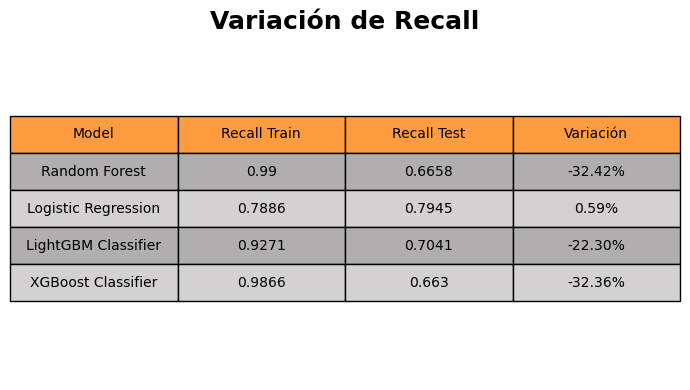

In [64]:
generar_tabla(df_recall_diff,
              title='Variación de Recall',
              save='recall_train_test',
              figsize=(7,4))

### <font color="#ffbf80">**Variación F1-Score**</font>

In [65]:
df_f1_diff

,Model,F1-score Train,F1-score Test,Variación
0,Random Forest,0.9906,0.6759,-31.47%
1,Logistic Regression,0.7832,0.5765,-20.67%
2,LightGBM Classifier,0.9372,0.6955,-24.17%
3,XGBoost Classifier,0.9885,0.6722,-31.63%


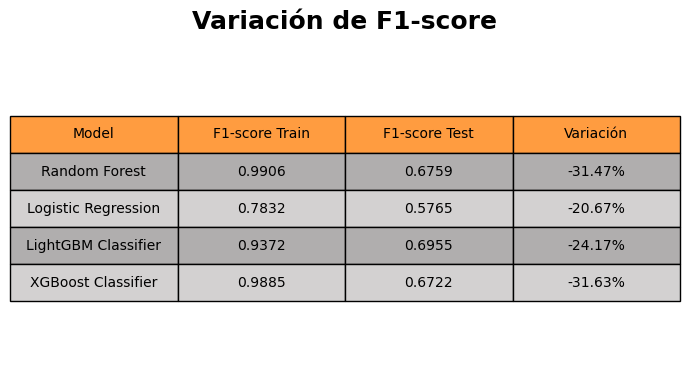

In [66]:
generar_tabla(df_f1_diff,
              title='Variación de F1-score',
              save='f1_train_test',
              figsize=(7,4))

## <font color='#b23200'>**Conclusiones: Subajuste (Underfitting) y Sobreajuste (Overfitting)**</font>

El análisis de las brechas de rendimiento entre los conjuntos de entrenamiento (Train) y prueba (Test) revela patrones claros sobre cómo cada algoritmo está aprendiendo (o memorizando) los datos:

1. **Sobreajuste Severo (High Variance) en Random Forest y XGBoost:**

>Ambos modelos exhiben un caso de libro de texto de Overfitting.Diagnóstico: Logran métricas casi perfectas en entrenamiento ($Recall \approx 99\%$), lo que indica que han "memorizado" el ruido y las particularidades del set de entrenamiento.Síntoma: Al enfrentarse a datos nuevos (Test), su rendimiento se desploma drásticamente, con una caída del ~32% en Recall.Conclusión: Estos modelos son demasiado complejos para la cantidad de datos disponibles o requieren una regularización mucho más agresiva (poda de árboles, min_samples_leaf más alto) para ser útiles en producción.
  
3. **Sobreajuste Moderado en LightGBM:**

>Si bien LightGBM también presenta una caída notable en el desempeño (Variación del -22.30% en Recall), su comportamiento es estructuralmente más robusto que sus competidores de árboles:Mantiene un Recall en Test superior ($0.70$ vs $0.66$ de RF/XGB), lo que demuestra una mejor capacidad de generalización.Su F1-Score en Test ($0.6955$) es el más alto de los modelos complejos, indicando que la caída, aunque existente, conserva mejor el balance entre Precisión y Recall.

4. **Estabilidad vs. Subajuste (High Bias) en Regresión LogísticaEl modelo lineal muestra el comportamiento opuesto:**

>**Estabilidad:** Es el único modelo donde el Recall en Test es incluso superior al de Train ($+0.59\%$), lo que indica una Varianza muy baja. El modelo es consistente.Techo de Rendimiento (Underfitting): Sin embargo, su desempeño en entrenamiento ($0.78$) es significativamente inferior al potencial demostrado por los árboles ($0.99$). Esto sugiere Sesgo Alto: el modelo es demasiado simple para capturar la complejidad no lineal de las relaciones entre las variables (ej. comportamiento transaccional complejo), limitando su techo de efectividad.


### **Conclusión:**

Existe un claro trade-off entre la capacidad de aprendizaje (Árboles) y la estabilidad (Lineal). Se selecciona `LightGBM Classifier` como el compromiso óptimo, ya que ofrece la mejor capacidad de generalización dentro de los modelos de alto rendimiento, mitigando el overfitting severo de `XGBoost Classifier` y `Random Forest` y superando el techo de complejidad de la `Logistic Regression`

## <font color="#ff743d">**Matrices de Confusión**</font>

rf = 0.4, lr = 0.56, lgbm=0.39, xgb = 0.31

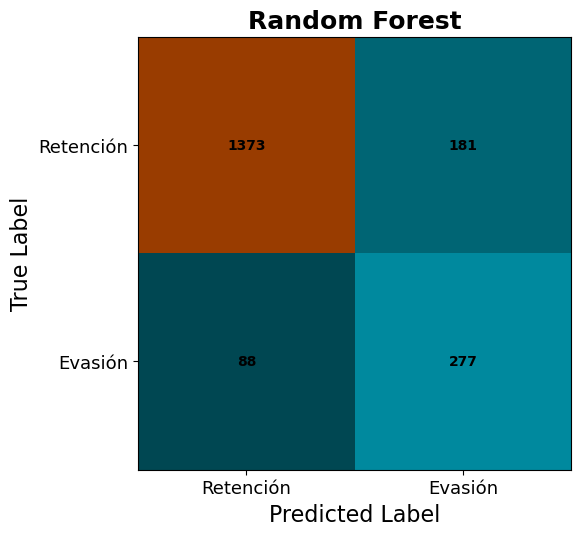

In [67]:
plot_conf_mat(model=rf,
              x=X_test,
              y=y_test,
              name='Random Forest',
              save='rf',
              umbral=0.4)

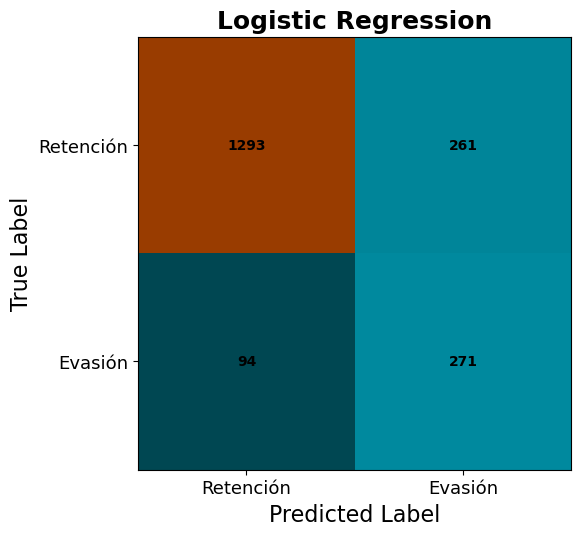

In [68]:
plot_conf_mat(model=lr,
              x=X_test,
              y=y_test,
              name='Logistic Regression',
              save='lr',
              umbral=0.56)

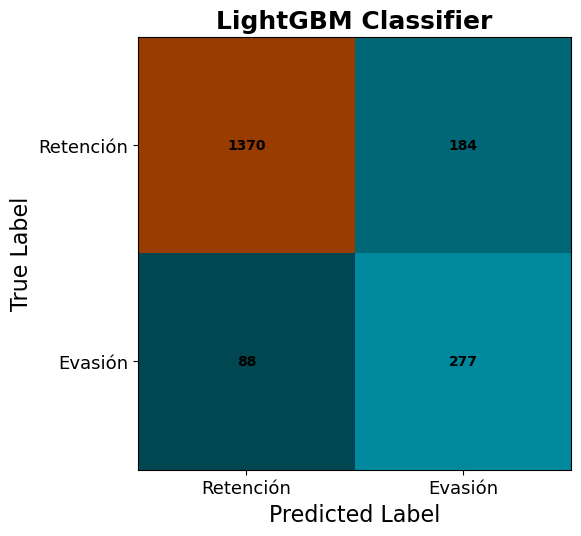

In [69]:
plot_conf_mat(model=lgbm,
              x=X_test,
              y=y_test,
              name='LightGBM Classifier',
              save='lgbm',
              umbral=0.39)

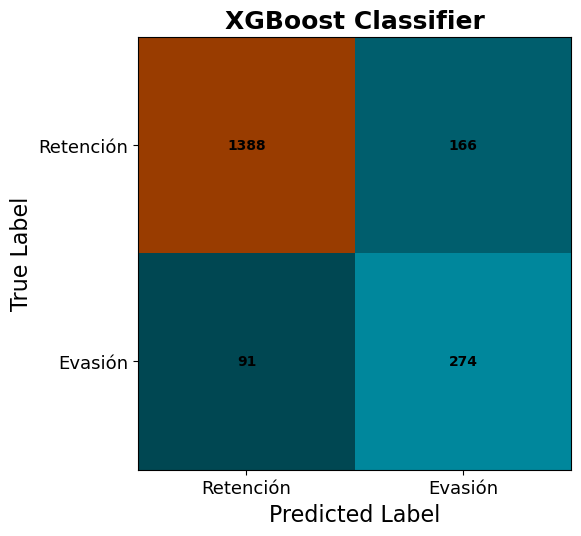

In [70]:
plot_conf_mat(model=xgb,
              x=X_test,
              y=y_test,
              name='XGBoost Classifier',
              save='xgb',
              umbral=0.31)

## <font color='#b23200'>**Conclusiones: Matrices de Confusión**</font>

En las matrices de confusión se evidencia de manera gráfica lo analizado en el apartado de **Métricas Generales y Umbrales de Decisión**.

Pero como se mencionó en la sección de **Subajuste (Underfitting) y Sobreajuste (Overfitting)**, el modelo `LightGBM Classifier` muestra una robustez superior a los demás modelos, por lo que se analizará el desempeño del mismo para su puesta en producción.

# <font color="#6e8ebc">**Champion Model: LightGBM Classifier**</font>

## <font color="#ff743d">**Importancias**</font>

In [71]:
lgbm.feature_importances_

array([156,  25, 116,  13, 217,  44, 207, 327,  73, 145,  21,  43, 179,
        59, 148,  51,  33, 203, 105, 178,  23,  12,  25])

In [72]:
split_importancias = lgbm.feature_importances_

total_importancias = split_importancias.sum()

importancias_norm = split_importancias / total_importancias


df_importancias = pd.DataFrame({'Feature': X_train.columns, 'Importancia': importancias_norm})
df_importancias.sort_values(by='Importancia', ascending=False, inplace=True)

In [73]:
df_importancias

,Feature,Importancia
7,NumOfProducts,0.136080
4,Age,0.090304
6,Balance,0.086142
17,days_since_last_ss,0.084478
12,days_since_last_tx,0.074490
19,ss_q2q3_rate_of_change,0.074074
0,Geography_Germany,0.064919
14,tx_q2q3_rate_of_change,0.061590
9,IsActiveMember,0.060341
2,Gender_Male,0.048273


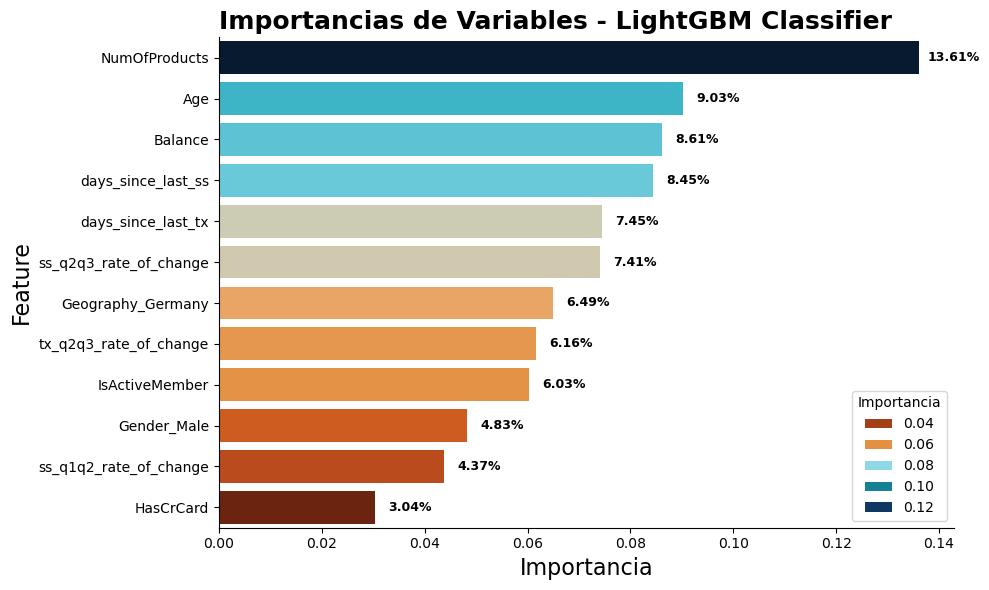

In [74]:
plot_analisis_variables(df=df_importancias,
                        analisis='Importancia',
                        nombre_modelo='LightGBM Classifier',
                        n_vars=12,
                        save='lgbm_importances',
                        save_path=IMG_PATH,
                        space=0.05
                       )

## <font color="#ff743d">**Análisis SHAP**</font>

In [75]:
import shap

In [76]:
explainer = shap.TreeExplainer(lgbm)

In [77]:
import warnings

try:

    with warnings.catch_warnings():
        warnings.filterwarnings(
            'ignore', 
            message='LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray', 
            category=UserWarning
        )
        
        shap_values = explainer.shap_values(X_test)
        print('Cálculo SHAP completado.')
        
    shap_values_churn = shap_values[1] 
    print('Acceso a shap_values[1] exitoso.')
        
except Exception as e:
    print(f'Error durante el cálculo o acceso a SHAP!: {e}')
    import traceback
    traceback.print_exc()

Cálculo SHAP completado.
Acceso a shap_values[1] exitoso.


In [78]:
shap_values_churn

array([-1.40818018e-01, -5.96170531e-03, -3.18467425e-01, -2.77492277e-02,
       -1.11041511e+00, -2.01132166e-02,  4.27814521e-02, -8.04978137e-01,
       -1.10887565e-02, -4.25380828e-01, -7.88463028e-03, -2.78162133e-02,
       -4.87339690e-01,  3.09302097e-02, -1.98488906e-01, -2.70112495e-02,
        1.14930390e-02, -1.83329741e-01,  1.00703713e-01, -4.28825289e-01,
       -8.25144791e-03, -9.68438984e-04, -1.27962751e-02])

In [79]:
len(shap_values_churn)

23

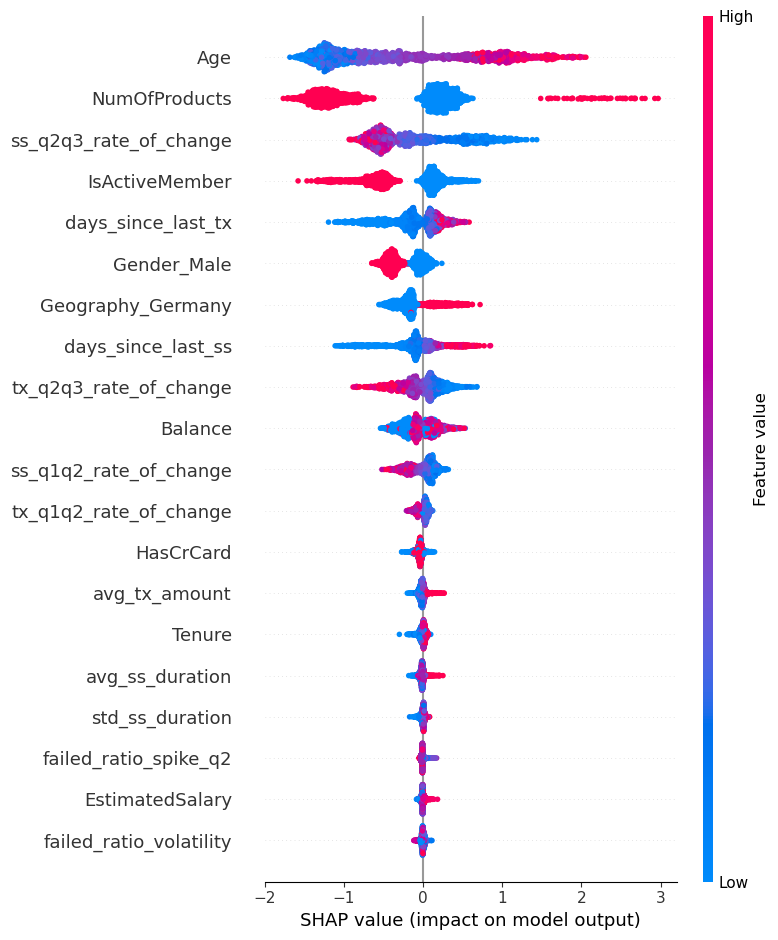

In [80]:
shap.summary_plot(shap_values, X_test, plot_type='dot')
plt.show()

A partir del resumen de valores shap, podemos observar la importancia global de cada feature y como los valores de cada variable influyen en las predicciones del modelo. 

Antes de desarrollar el análisis, se consideran los siguientes aspectos del gráfico:

* Valores negativos de SHAP indica que dichas observaciones contribuyen a la retención (o impactan de forma negativa en el abandono). Valores positivos de SHAP contribuyen al abandono (impactan de forma postiva en el Churn).
* Escala de colores:
  - Rojos para valores altos de la variable observada.
  - Azules para valores bajos de la variable observada.
* La concentración de puntos representa la cantidad de observaciones en dicho valor SHAP.

De mayor a menor relevancia

> **`Age`:** Es el mayor predictor individual. Se puede observar que valores elevados en dicha variable conllevan un fuerte SHAP positivo, los cuales contribuyen a la evasión. Esto confirma lo que se visualizó en el script de EDA: existe una gran concentración de clientes que abandonan entre 38 y 51 años. 

> **`NumOfProducts`:** Si bien es posible observar que gran concentración de puntos rojos presentan valores negativos de SHAP, también existe un grupo que contribuyen positivamente al abandono. Esto podría indicar descontento con la integración de servicios, o quizás con algun servicio en particular.

> **`ss_q2q3_rate_of_change`:** Valores altos contribuyen a la retención, mientras que valores bajos están fuertemente asociados al abandono. Una dimsinución en la frecuencia del uso de la aplicación en el último período (este feature evalúa la tasa de cambio entre en segundo y tercer trimestre) es una fuerte señal de abandono.

> **`IsActiveMember`:** Como es de esperarse, que un cliente esté clasificado como "Activo", contribuye a la retención, mientras aquellos que no interactúan con la empresa tienen valores SHAP positivos.

> **`days_since_last_tx`:** Valores altos contribuyen al abandono. Mientras más tiempo lleva un cliente sin realizar transacciones, más probable es que este abandone.

> **`days_since_last_ss`:** Al igual que con **days_since_last_tx**, valores elevados en esta variable tienen un impacto positivo en las probabilidades de abandono, es decir, aumentan. Mientras más tiempo lleva un cliente sin conectarse a la aplicación, más probabilidades hay de que abandone.

> **`Gender_Male`:** Dado que esta variable es binaria, los puntos rojos representan **Gender_Male = 1**, por lo que, a partir de los valores SHAP de esta variable, podemos confirmar lo que se analizó en el Análisis Exploratorio de Datos (EDA): ser mujer contribuye al abandono. Lo cual podría indicar sesgos o desigualdad en oportunidades, productos u ofertas.

> **`Geography_Germany`:** También siendo una variable binaria, se observa que para valores **Geography_Germany = 1**, el SHAP value es positivo, lo cual refleja que ser alemán aumenta las probabilidades de abandono. Reflejando que existen problemas dentro de este país en particular.

> **`tx_q2q3_rate_of_change`:** Valores altos contribuyen a la retención, mientras que valores bajos están fuertemente asociados al abandono. Una dimsinución en la cantidad de transacciones realizadas en el último período (este feature evalúa la tasa de cambio entre en segundo y tercer trimestre) es un fuerte indicador de abandono.

> **`ss_q1q2_rate_of_change`:** Mide lo mismo que **ss_q2q3_rate_of_change** pero entre el primer y segundo trimestre. De aquí destaca que, el hecho de que ambas tasas de cambio en la cantidad de sesiones aparezcan entre los 10 mayores predictores, indica que monitorear el cambio en el comportamiento del cliente referente al uso de la aplicación será clave para predecir el abandono e intervenir clientes efectivamente para aplicar estrategias de retención.

> **`Balance`:** Aquí surge un factor contraintuitivo, y posiblemente crítico. Valores elevados en el Balance contribuyen a aumentar las probabilidades de abandono del cliente. Esto refleja el hecho de que la mayoría de clientes que decidieron abandonar, eran clientes de alto valor (factor observado en el script de Análisis Exploratorio de Datos (EDA)). 

In [81]:
shap.summary_plot(shap_values, X_test, plot_type='dot', show=False) 
plt.savefig(IMG_PATH /'shap_summary_plot.png', bbox_inches='tight', dpi=150)
plt.close()

Buscando umbrales lógicos...


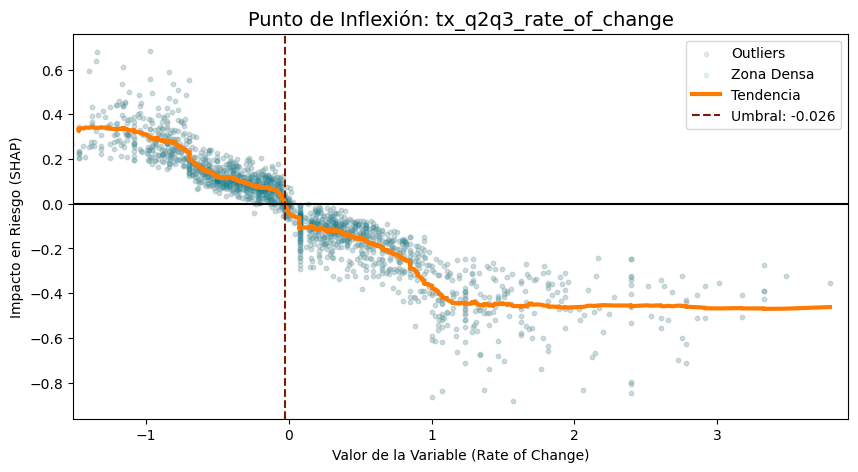

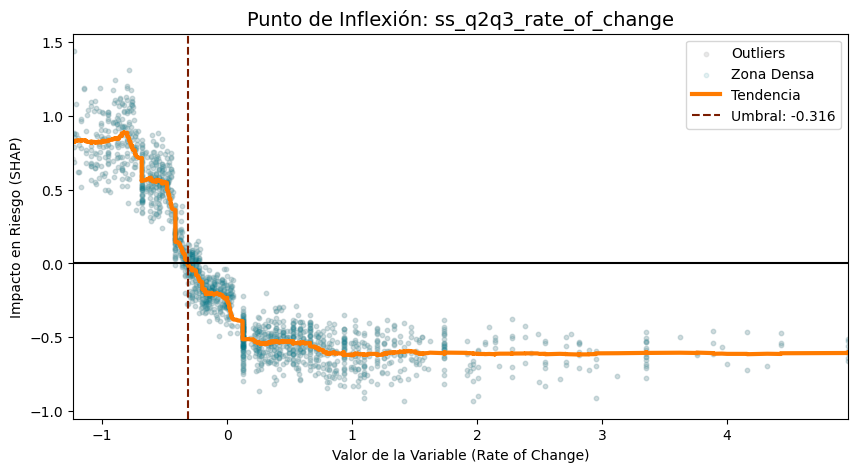


📊 UMBRALES CRÍTICOS:
Transacciones: Alerta si cae por debajo de -0.03
App Sessions:  Alerta si cae por debajo de -0.32


In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def encontrar_punto_critico_robusto(feature_name, X_test, shap_values, q_min=0.01, q_max=0.99):
    """
    Encuentra el umbral crítico ignorando outliers extremos.
    """
    # 1. Preparar datos
    feature_vals = X_test[feature_name].values
    shap_vals = shap_values[:, X_test.columns.get_loc(feature_name)]
    
    df_analysis = pd.DataFrame({'val': feature_vals, 'shap': shap_vals})
    
    # 2. FILTRO DE SEGURIDAD (La clave del arreglo)
    # Solo miramos entre el percentil 1% y 99% para evitar que un outlier de valor 81 rompa el análisis
    lower_bound = df_analysis['val'].quantile(q_min)
    upper_bound = df_analysis['val'].quantile(q_max)
    
    df_focused = df_analysis[(df_analysis['val'] >= lower_bound) & (df_analysis['val'] <= upper_bound)].sort_values(by='val')
    
    # 3. Suavizado (Rolling Mean)
    # Aumentamos el window para que la curva sea más estable
    df_focused['shap_smooth'] = df_focused['shap'].rolling(window=100, center=True, min_periods=10).mean()
    
    # 4. Encontrar el cruce de CERO (Zona de Riesgo vs Zona Segura)
    # Buscamos el punto donde el impacto cambia de signo
    # (Típicamente buscamos pasar de Positivo [Riesgo] a Negativo [Seguro] a medida que aumenta la actividad)
    df_clean = df_focused.dropna()
    idx_cruce = (df_clean['shap_smooth'].abs()).idxmin()
    umbral_critico = df_clean.loc[idx_cruce, 'val']
    
    # --- GRAFICAR ---
    plt.figure(figsize=(10, 5))
    # Puntos grises: Todos los datos (incluyendo outliers para contexto)
    plt.scatter(df_analysis['val'], df_analysis['shap'], color='lightgray', alpha=0.5, s=10, label='Outliers')
    # Puntos azules: Zona de análisis
    plt.scatter(df_focused['val'], df_focused['shap'], color=CIELO_2, alpha=0.1, s=10, label='Zona Densa')
    # Línea roja: Tendencia
    plt.plot(df_clean['val'], df_clean['shap_smooth'], color=NARANJA_3, linewidth=3, label='Tendencia')
    
    plt.axvline(umbral_critico, color=ROJO_1, linestyle='--', label=f'Umbral: {umbral_critico:.3f}')
    plt.axhline(0, color='black', linestyle='-')
    
    # Limitar el zoom del gráfico a la zona interesante
    plt.xlim(lower_bound, upper_bound)
    plt.title(f'Punto de Inflexión: {feature_name}', fontsize=14)
    plt.xlabel('Valor de la Variable (Rate of Change)')
    plt.ylabel('Impacto en Riesgo (SHAP)')
    plt.legend()
    plt.show()
    
    return umbral_critico

# --- EJECUCIÓN ---
print("Buscando umbrales lógicos...")
umb_tx = encontrar_punto_critico_robusto('tx_q2q3_rate_of_change', X_test, shap_values)
umb_ss = encontrar_punto_critico_robusto('ss_q2q3_rate_of_change', X_test, shap_values)

print(f"\n📊 UMBRALES CRÍTICOS:")
print(f"Transacciones: Alerta si cae por debajo de {umb_tx:.2f}")
print(f"App Sessions:  Alerta si cae por debajo de {umb_ss:.2f}")

# <font color="#6e8ebc">**Guardado de Artefactos para Entorno Productivo**</font>

In [84]:
rango_umbrales = np.round(np.linspace(0.49, 0.10, 40), 2)
umbral_decision = 0
for umbral in rango_umbrales:
    resultado_umbral = metricas_evaluacion(modelo=lgbm,
                                           stage='Test',
                                           x= X_test,
                                           y= y_test,
                                           nombre='LightGBM Classifier',
                                           umbral=umbral)
    
    if resultado_umbral['Recall'] > 0.75:
        umbral_decision = umbral
        break

umbral_decision

0.39

In [85]:
# Función auxiliar para guardar (para no repetir código)
def guardar_archivo(objeto, ruta, nombre_archivo):
    try:
        with open(ruta / nombre_archivo, 'wb') as f:
            pickle.dump(objeto, f)
        print(f"Guardado: {ruta}")
    except Exception as e:
        print(f'Error al guardar {nombre_archivo} en {ruta}')
        print(e)

# --- GUARDAR ARTEFACTOS CARPETA CHAMPION---

# OneHotEncoder
guardar_archivo(one_hot, CHAMPION_PATH, 'encoder.pkl')

# Scaler
guardar_archivo(scaler, CHAMPION_PATH,'scaler.pkl')

# El orden de las columnas
guardar_archivo(col_order, CHAMPION_PATH,'columns.pkl')

# Modelo 
guardar_archivo(lgbm, CHAMPION_PATH,'champion_model.pkl')

# Umbral de decisión
guardar_archivo(umbral_decision, CHAMPION_PATH, 'umbral_decision.pkl')

# --- GUARDAR ARTEFACTOS CARPETA API/ARTIFACTS

# OneHotEncoder
guardar_archivo(one_hot, ARTIFACTS_PATH, 'encoder.pkl')

# Scaler
guardar_archivo(scaler, ARTIFACTS_PATH,'scaler.pkl')

# El orden de las columnas
guardar_archivo(col_order, ARTIFACTS_PATH,'columns.pkl')

# Modelo 
guardar_archivo(lgbm, ARTIFACTS_PATH,'champion_model.pkl')

# Umbral de decisión
guardar_archivo(umbral_decision, ARTIFACTS_PATH, 'umbral_decision.pkl')

# Umbral de decisión
guardar_archivo(umb_tx, ARTIFACTS_PATH, 'umbral_critico_tx_q2q3.pkl')

# Umbral de decisión
guardar_archivo(umb_ss, ARTIFACTS_PATH, 'umbral_critico_ss_q2q3.pkl')

print("\n¡Artefactos guardados'!")

Guardado: C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\champion
Guardado: C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\champion
Guardado: C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\champion
Guardado: C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\champion
Guardado: C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\champion
Guardado: C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\api\artifacts
Guardado: C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\api\artifacts
Guardado: C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\api\artifacts
Guardado: C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\api\artifacts
Guardado: C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\api\artifacts
Guardado: C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\api\artifacts
Guardado: C:\Users\Ignacio\OneDrive\Desktop\ha